# Feature analysis — cross-exchange book-pressure gap (`xv_book_pressure`)

This notebook is two things at once: a **method** for analysing a trading feature, and a
**worked example** of that method on one feature. The text explains what to do and why; the
code does it.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead.
Three crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) —
and **byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best
buy and best sell quote.) The next section explains the model these features feed.

To analyse a new feature, copy this notebook and change the parts specific to the feature:
**what it is and why** (§1), **its exact definition** (§2), and **its builder** — the
`book_pressure` function in §3. The data loading, the checks, and the plots adapt on their own.

**The example** is `xv_book_pressure`: the **gap** between another exchange's *book pressure* and
byb's. Book pressure is read two bounded ways at the top of the book — **queue imbalance** (is
there more size resting on the bid or the ask?) and the **micro-price premium** (does the
size-weighted fair price sit above or below the mid?). When another venue's book leans before byb's
does, that cross-venue gap predicts which way byb's mid moves next.

**A feature's *analysis* is done when two checks pass:**
- **The parity check (§4)** — a second implementation reproduces the feature on real data, so the code really computes what we think it does.
- **The hygiene gates (§5)** — the signal is real and holds in any market, not just an echo
  of "the market is volatile right now."

Everything after that decides *which part of the model* the feature feeds, and *at what
time-scale* — and the §10 checklist (streaming builder, tests, multi-block OOS) gates **shipping**: analysis-done is not ship-done.

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what
the model does. We forecast how byb's mid-price moves over the next ~100 ms, and we split
that into two simpler questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed*
move (its direction *and* its size, together)? The head predicts the whole distribution of
that move, in units of byb's recent **volatility** — the **volatility yardstick** `σ_ev`
(the exp-weighted RMS of byb's *actual* mid-moves) — so the head's target is
`price change ÷ σ_ev`.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet
ones few. This head predicts the *count* of moves over the next 100 ms as a distribution,
measured against the recent pace — the **rate yardstick** `λ_ev` — so its target is
`count ÷ λ_ev`.

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move
*rate* (`λ_ev`), from past data only. A regime gauge, nothing more. When a feature *carries* that regime and you want it gone, dividing
by the yardstick is **one option** for removing it (only *when applicable* — you can't always
divide the regime out of a feature). Both are EMAs **decayed on the trade clock** (`α = 2/(span+1)`)
but **updated between trades** — they react to every byb mid-move, so they read live at every
instant. They use one fixed span, `YARDSTICK_N` (any feature may use that span too). (`σ_ev` is
the exp-weighted RMS of byb's *actual* mid-moves — read as an `E/W` ratio so the many non-move
trades cancel out; `λ_ev` is a ratio of two EMAs — the exp-weighted byb move-count `W` (the same
`W` that is `σ_ev`'s denominator) ÷ the exp-weighted seconds-per-trade = byb's moves per second.) Like every average here, they live
on the trade-tick clock — never wall-clock or a hard window.

**Why split into two heads?** A move over a window is just *how many* little moves happen
times *how big* each one is. Pulling "how many" (rate) apart from "how big" (price) lets each
head learn a steadier thing — and is why there are two yardsticks, one per head.

**Putting them back together.** The price head isn't a single distribution — it's a *family*,
one per possible move-count: "if `k` moves happen, here's the spread of the total price
change" (call it `D_k`). The rate head gives the probability of each count, `P(K = k)`. The
100 ms move is the two **mixed** — for every count `k`, take the price head's `k`-move
distribution, weight it by the rate head's probability of exactly `k` moves, and sum:

`distribution of the 100 ms move  =  Σ_k  P(K = k) · D_k`

More moves → a wider spread, so the rate head's "how many" sets the scale and the price head's
`D_k` sets the shape. This is why a feature that predicts the *count* (rate head) and one that
predicts the *per-move direction* (price head) are both useful: they feed the two factors that
multiply together.

**Backed by research.** This "how many × how big" split is the classic **subordination** model
of asset prices (Clark, 1973, *Econometrica*; Ané & Geman, 2000, *Journal of Finance*): returns
over a fixed clock-time window look messy, but become well-behaved once you condition on the
*number* of events. So modelling the event count and the per-event move separately, then mixing
them, is a principled decomposition — not just a convenient one.

Every feature here feeds one or both heads, and borrows the matching yardstick when it needs
to be made comparable across markets. Two questions recur below: does a feature's *signed*
value predict the move (price head), and does its *magnitude* predict how many moves come
(rate head)? Those are diagnostics — the model is fed the **signed** feature for *both* heads,
and the rate head learns the magnitude (and how features cancel or reinforce) on its own. And they
are **marginal screens** — does the feature carry signal worth feeding — **not** measures of
distributional fit: the model's actual targets are the count distribution `P(K = k)` and the
count-conditioned price family `D_k` mixed above, fit downstream, not what these rank-ICs measure
(§7 inspects the realised count/return distributions by feature bucket).

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads — leadership moves around. Build
  the gap the same way for every source venue and keep them all.
- **Don't pick "the best exchange"** by average score — that throws away the moments another
  exchange leads (often the most informative ones). Keep all; let the model weight them.
- **Don't pool exchanges by default.** This feature is already a *gap between* venues, so it is
  per-source by construction (§9 covers when pooling is genuine for poolable features).
- **Don't normalize reflexively.** Divide volatility or rate out of a feature *only when it
  needs it* — a difference of **bounded** atoms (queue imbalance ∈ [−1, 1], a tiny premium ratio)
  is already comparable across markets, so it needs **no** vol/rate division. (Contrast the
  template's price gap, which is bigger when volatile and so *must* be divided by `σ_ev`.) But
  that is a claim to *measure*: build it RAW and only normalise if §6's scale gate fails.
- **Don't invent your own vol/rate scale.** When you *do* normalize, use the model's yardstick
  (`σ_ev` or `λ_ev`), so the feature shares units with the target.
- **Don't trust a correlation** until it survives the regime controls (rate and vol) — else
  it may just be re-reporting "the market is volatile."
- **Don't ship a feature without the §4 parity check** — a second, production-style build reproducing it on real data.
- **Don't hand-roll a streaming EMA, and don't use `EventEMA` — use only `KernelMeanEMA` or `LiveFrontEMA`.**
  Every *online* average — the §4 production/streaming parity build, and any event-by-event EMA state anywhere
  in the notebook — MUST be exactly one of **two** `boba.ema` classes: **`KernelMeanEMA`** (the self-normalising
  `E / W` read — for a **flow**) or **`LiveFrontEMA`** (the live-front read — for a **level**). Both expose
  **separate `tick()` (decay) and `add()` (inject)** calls — that separation is the whole point: decay rides the
  shared trade clock (once per trade-timestamp) while injection rides each relevant-event timestamp, and the two
  must fire **independently** (see the inject-≠-decay rule below). **Never use `EventEMA`:** its single `step()`
  **couples decay and injection** into one call, so it *cannot* decay on the trade clock while injecting on a
  different event stream — that directly violates the inject-once / decay-once-independently rule. And **never**
  hand-roll a scalar EMA (no private `_ScalarEMA`, no `(1−α)·s + α·x` per-event loop) or reach for
  `scipy.signal.lfilter` in the streaming build. Every quantity here is either a **flow** (→ `KernelMeanEMA`) or
  a **level** (→ `LiveFrontEMA`); if you think you need anything else, you've mis-modelled it (a slope/covariance
  is a ratio of flow EMAs — several `KernelMeanEMA`s, not a bespoke class). §4 exists to validate the **actual
  production code** (`boba.ema` online vs §3's vectorized path), not a throwaway re-implementation that could
  carry the same blind spot. (The §3 *vectorized* analysis may still use `lfilter` — the offline array path, not
  online EMA state.)
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp.
- **Don't use a hard window.** No rolling max/min, no fixed-N lookback buffer; every smoother is a
  trade-clock EMA, never a boxcar.
- **Don't over-transform for the network.** Pick the lightest reshaping that works.

**Do**
- **Do start with a falsifiable hypothesis** — a mechanism for why it should work, and what
  would prove it wrong.
- **Do make every average a trade-tick EMA.** *Every* smoother in the pipeline — each gap leg,
  `σ_ev`, `λ_ev`, any rolling statistic — is an exponential moving average
  **decayed once per tick of the one shared trade clock** (one tick per trade-timestamp across **all** venues; simultaneous prints count once; `α = 2/(span+1)`) yet **taking in a fresh value at most once per timestamp that carries a relevant event** (a book update of either venue — same-timestamp events as one update, never stale between trades), **never** a wall-clock
  average and **never** a hard/boxcar window. That keeps the whole state **O(1)** (one scalar
  per average, no ring buffers) and bit-identical online vs offline. Establish and validate the
  convention against a plain one-event-at-a-time loop on a real block — exactly as
  `notebooks/03_ema_clock_validation.ipynb` does, and as the §4 parity check re-checks here.
- **Do make every EMA react to relevant events as they land — never let it read a stale state.** An EMA's
  *decay* lives on the trade clock, but it must *update its value* at **each timestamp that carries a
  relevant event** (same-timestamp events aggregated to one update). For this gap, that relevant event is a book
  update of *either* venue (byb or the source): the leg refreshes its front to that timestamp's gap. A value that
  ignores the book updates since the last trade is **stale** — wrong, and a silent source of lag. The choice of
  EMA *and when it updates* is what makes the inter-trade read well-behaved — pick both deliberately (see the
  "Choosing the EMA" section).
- **Do inject at most one EMA sample per timestamp, and decay once per shared-trade-clock tick — this
  never changes.** At each timestamp an EMA injects **one** sample *iff* a relevant event for that EMA
  lands there: for a gap leg, a book update of either venue refreshes the live front; for `σ_ev`, a byb mid-move
  pushes its return². A timestamp with only **irrelevant** events injects nothing for that EMA, yet it still
  **ticks** (decays) once *iff* a trade lands, on the one **shared** trade clock
  (one tick per trade-timestamp across **all** venues, simultaneous prints counting once). Inject and
  decay are independent and neither ever fires more than once per timestamp, whatever the feature.
  Records sharing a timestamp are **one** sample, not a sequence: same-timestamp aggregation sets only
  that sample's **value** — never the number of samples, never the number of ticks. *What* value depends on the quantity: a **level**
  read takes the *last* state (mid, microprice, the book atoms); a **flow** **sums** the records at that
  timestamp (`σ_ev`'s return², trade volume). The book-pressure gap is a **level**: a burst of N book updates at
  one instant is still **one** weight-1 sample — value = the final book's atom gap — **never** N samples.
- **Do always read the *freshest* value — never freeze on the last trade's.** Each gap leg is a
  trade-weighted EMA with a **live front**: `read = (1 − α)·committed + α·current_gap`, current at
  every instant between trades. Keep the two clocks separate: refresh the *read* at each book-update
  **timestamp** (one per timestamp, not per message), but keep the *decay/weighting* on the trade clock.
  Pushing per book *message* would quote-churn-weight a clean trade-weighted level (measurably worse).
  (Freshness itself measured ≈neutral for a 100 ms target — so reading fresh costs nothing and is the right
  default; never deliberately use stale information.)
- **Do test against both heads — but feed both the *signed* feature.** Check whether the
  signed gap predicts *direction* (price head) and whether its *magnitude* predicts
  *intensity* (rate head). Those checks are diagnostics — in the model, feed the **signed**
  gap to *both* heads, never a pre-computed `|gap|`. The rate head will learn the
  magnitude itself, *and* learn that a +gap on one source can cancel a −gap on another
  (or reinforce it). Pre-taking `|·|` per feature destroys the sign and that interaction.
- **Do score out-of-sample** with a purged, embargoed walk-forward (strictly past→future) — a single split is only a faster screen.
- **Do use the freshest valid price/book per exchange.**
- **Do treat a feature as a family across time-scales** and let the data assign scales to heads.
- **Do prove regime-invariance with Gate A — never assume it.** A usable feature reads the *same* in calm and
  wild markets: its distribution must be **stable against the regime diagnostics we track** (not a proof of independence). Gate A's **control-free** checks (§6):
  **scale** (std stable across vol buckets, max/min < ~3); and — for **both the signed feature and its
  magnitude `|feature|`** (the rate head sees the signed feature but can learn its magnitude) — that it does **not track** the regime
  (`|IC(·, vol & rate level)| ≈ 0`, the monotone test) **nor leak non-monotonically** (per-decile-mean
  **dispersion** small, which catches a U-shaped leak the monotone IC misses). All are **hard** gates. A raw
  **level** (`σ_ev`, `λ_ev`, a mean trade size) usually *is* the regime and fails them — but *measure, don't
  assume*: a **ratio / bounded / normalised** form may pass (this gap is a difference of **bounded** atoms, so expect it to pass — but measure), and even a ratio of two non-invariant levels can
  be invariant when they co-move. Never call a feature regime-invariant *or* not — nor a level useless — until
  **every** Gate A number says so. (Corollary: don't assert *any* property — invariance, a lead/lag, "it's
  circular" — you haven't measured on a real block.)
- **Don't fuse the two gates — they're independent.** *Regime invariance* (Gate A) is the feature's own
  distribution being stable across regimes; *signal* (Gate B) is what it predicts over the **invariant**
  controls. The raw vol/rate **levels aren't Gate-B controls** (they aren't valid alpha features) — putting them in
  the signal test just smuggles the Gate-A regime test back in; they serve only as the Gate-A regime *coordinate*. And **a control can be a valid feature**: when the
  feature under test *is* a regime descriptor, marginal-over-its-own-controls is circular — judge it on its
  **standalone** signal, and never call it "redundant" from its algebra alone.

## 1. What the feature is, and why it might work

Every feature starts with a one-line summary and a **hypothesis you could be wrong about**.
If there's no story for *why* it should predict anything, don't bother testing it.

| | |
|---|---|
| **what** | the GAP between another exchange's top-of-book *pressure* and byb's, smoothed over a time-scale family — two bounded atoms, per source venue |
| **feeds** | both heads — *direction* (price head: which way byb moves) and *intensity* (rate head: how many moves); both are fed the *signed* gap |
| **predicts** | byb's mid-price 100 ms from now |

**The two atoms.** At the top of each venue's book, read pressure two bounded ways:
- **queue imbalance** `QI = (bid_qty − ask_qty)/(bid_qty + ask_qty) ∈ [−1, 1]` — is there more
  size resting on the bid (`+`, buyers leaning in) or the ask (`−`)?
- **micro-price premium** `prem = (microprice − mid)/mid`, with the size-weighted fair price
  `microprice = (bid_qty·ask_prc + ask_qty·bid_prc)/(bid_qty + ask_qty)` — the microprice leans
  toward the **heavier** side, so `prem > 0` when the bid is heavier, `< 0` when the ask is.

Both are **bounded, dimensionless** reads of the same imbalance, from slightly different angles
(QI weights raw size; prem weights size *and* folds in where the quote sits).

**The feature: the cross-venue GAP.** For each other venue `o ∈ {okx, bin}` and each atom, take
`gap = atom(o) − atom(byb)` and smooth it on byb's trade clock over a span family. A **short**
span catches the *lead* — one venue's book leaning a beat before byb's; a **long** span catches a
*structural skew* — a persistent difference in how the two books sit.

**Why it might work — and the sign is itself the test.** Order books across venues don't lean in
lockstep — one tends to build pressure a beat before the others, and there are two opposite mechanisms,
with **opposite signs**, so the measured sign *is* a falsifiable prediction:
- **Lead/lag (positive sign):** if okx's book leans bid-heavy while byb's isn't yet, byb's mid ticks
  **up to follow** — gap and next byb return share a sign.
- **Catch-up / stale-book mean-reversion (negative sign):** if the gap is mostly byb's *own* book being
  staler (it hasn't refreshed to where the fresher venues already are), then as byb refreshes its mid
  moves **opposite** to the measured gap — gap and next return have opposite signs.

§1's first instinct is the positive lead. **We rewrite this section after the run** — the executed §6/§7
sweeps decide which mechanism the block actually shows, and the verdict (§10) is written to that measured
sign, not to the guess. That is why the **echo-netting check** is load-bearing: a sign on a book-imbalance
gap could be re-reporting the byb move already underway at the anchor, so we net the contemporaneous echo
out of the forward IC and report what survives, not the raw correlation.

**What would disprove it.** No predictive power at any span; power that vanishes once we account for
volatility (it was only tracking volatility); or a forward edge that **collapses once the contemporaneous
echo is netted out** (it was only re-reporting the move already underway, not predicting the next one).

> **No fixed leader.** It's tempting to call one exchange "the leader." Don't — leadership moves
> around. Build the gap the same way for every source venue and keep them all. (This feature is a
> *gap between* exchanges, so it's per-source anyway — §9 covers when pooling is genuine for poolable
> features.)

## Choosing the EMA

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per *trade-timestamp*
(`α = 2/(span+1)`), but its **value updates at most once per timestamp that carries the EMA's own
relevant event** (same-timestamp events as one update). The book-pressure gap is a **forward-filled
level** — each atom has a value at every instant — so it is the textbook case for the live-front read.
Choose the EMA type and injection rule for the statistic being measured.

**Choice 1 — which EMA, and how you read it** (`boba.ema`):

- A **forward-filled level** — defined at every instant (a price, an atom, a cross-venue gap): use
  **`LiveFrontEMA`**, which reads the committed mean carried one step toward the freshest value,
  `(1 − α)·committed + α·latest` — current between trades, never frozen on the last trade. The
  book-pressure gap is exactly this: each atom has a value at every instant, so the gap leg is a
  `LiveFrontEMA`.
- A **sparse flow** — present on only *some* events (byb's mid-moves): use **`KernelMeanEMA`**, the
  self-normalising `E / W`. The yardsticks `σ_ev` / `λ_ev` are this kind (used only for the **target**
  and the controls — the feature itself is raw).
- `KernelMeanEMA` and `LiveFrontEMA` are the **only** two classes you may use, and they share the
  `tick` / `add` / `value` interface (decay and injection are *separate* calls), so you A/B the two reads by
  swapping the class. (`LiveFrontEMA` composes a plain `EventEMA` internally for its committed part, but
  **never use `EventEMA` directly**: its single `step()` couples decay and injection, so it cannot decay on the
  trade clock while injecting on a separate event stream — the very thing the next section requires.)

**Choice 2 — *when* you push a value in** (the injection clock — a *separate* decision from the decay
clock). Decay is always once per trade-timestamp; injection is only for timestamps carrying the
quantity the EMA is measuring. The allowed patterns are:

| pattern | what it weights / measures | use for |
|---|---|---|
| commit every trade-timestamp; read refreshes each book-update timestamp | by **trade-dwell** — a value spanning more trades counts more | a level (the gap leg) |
| only on the feature's real event, skip irrelevant clock ticks | a **per-real-event mean** | a flow (`σ_ev`: push `r²` only on a byb move) |

Classify the timestamp for the EMA being updated. For the gap leg we **commit** the gap once per
trade-timestamp (trade-dwell weighting — the right average for a level) and **refresh** the live front
on every book update of either venue, so the read is current between trades, never frozen. `N = 1` sets
`α = 1`, collapsing the leg to the fresh gap itself (no smoothing).

Between trades:

- **React at every relevant timestamp, and read the freshest value.** Decay rides the trade clock, but the
  gap must *update* on every book-update timestamp of either venue (same-timestamp events as one update),
  and the read must reflect those updates since the last trade — never a stale snapshot.
- **Records sharing a timestamp are ONE update, not a sequence** — apply them all, then register a single
  update (the final book at that ns). (The §4 parity check enforces both rules.)

## 2. The exact definition

A definition has to get three things right.

**Causal** — it uses only data up to the moment it's computed; no peeking at the future. (A stray
forward-fill is the usual way to break this by accident.)

**Measured on the trade clock** — markets alternate busy and quiet, so we count progress in *trades*
(one tick per trade-timestamp on any venue — simultaneous prints are one tick) rather than in
clock-seconds; that keeps the feature's meaning steady whether trading is fast or slow. Book updates
between trades refresh what the EMA *reads*, but they do **not** advance the clock — only a trade does.

**Comparable across calm and wild markets** — here the atoms are already **bounded**: QI ∈ [−1, 1],
and the premium is a tiny dimensionless ratio. Their cross-venue *difference* is a difference of
bounded quantities, so we **expect it to be regime-invariant raw** — no `/σ_ev` needed. But that is
a claim to *measure*, not assume: §6's scale gate decides. We build the feature RAW and only
normalise if the gate fails.

Put it together — per source `o` and per atom `A ∈ {QI, prem}`:

**2a — The shape** (the whole idea, in one line):

`feature[o, A, N] = EMA_N( A(o) − A(byb) )`   — a trade-clock EMA of the cross-venue atom gap.

A fresh book-pressure lean on `o` that byb hasn't matched shows up as a non-zero smoothed gap; a
short `N` reads the lead, a long `N` the structural skew. Stop here and you have the feature — the
rest is making each piece correct.

**2b — The EMA we use, and how it updates** (applying the two choices above):

- **Each gap leg** `A(o) − A(byb)` is a **forward-filled level** — both atoms have a value at every
  instant — so it is a **`LiveFrontEMA`** read as a **live front**:
  `(1 − α)·(gap committed at the last trade) + α·(the gap right now)`. We **commit** the gap once
  per trade-timestamp (trade-dwell weighting, the right average for a level) and **refresh** the
  live front on every book update of *either* venue, so the read is current between trades. `N = 1`
  sets `α = 1`, collapsing the leg to the fresh gap itself (no smoothing).
  > **Heads-up, because it shapes the verdict:** the spans the heads actually pick below are **short**
  > — often `N = 1`. At `N = 1` the whole committed-EMA apparatus drops out and the feature *is* the
  > raw, instantaneous fresh gap `A(o) − A(byb)` read at the anchor (the live front is all-fresh,
  > `ema_commit` returns its input untouched). The smoothing machinery still matters for the longer
  > members and for the structural-skew reading, and the §4 parity check validates the `α = 1` path
  > explicitly — but don't read the long EMA discussion as describing what the shipped short members
  > do. The short members are an un-smoothed cross-venue book-pressure *difference*, nothing more.
- **`σ_ev` and `λ_ev`** (the yardsticks, used only for the **target** and the controls — the
  feature itself is raw) are a **sparse flow** read as `E / W`: push `byb_return²` only on a real
  byb mid-move, decay every trade, read `σ_ev = √(E/W)` = RMS move *per move*; `λ_ev` is the same
  move-count `W` ÷ an EMA of seconds-per-trade.

The cell below loads each venue's **book** (`front_levels`: bid/ask price **and** size — the atoms
need the resting quantity, which `merged_levels` deliberately omits), builds the shared trade
clock, and computes **both yardsticks** as `E/W` flows on that clock, span `YARDSTICK_N`. §3 builds
exactly this; §4 re-derives it from raw events and confirms it to float precision.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we predict (and the byb leg of every cross-venue gap)
SOURCES     = ["okx", "bin"]                      # the OTHER venues; each one's atom-gap vs byb is a feature (symmetric, no leader)
ATOMS       = ["QI", "prem"]                      # the two bounded book-pressure atoms; each makes its own gap family
# The atoms need the resting QUANTITY at the top of book, so every venue uses front_levels (bid/ask prc + qty).
# merged_levels is PRICE-ONLY (no qty by design — see boba.io) so it cannot supply the atoms. The byb mid used for the
# TARGET / yardsticks still comes from byb merged_levels (the freshest price); bin's mid uses front_levels (merged is
# DISALLOWED for bin perp). The atoms are book-only, so this split touches only the target/yardstick side.
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}
SPANS       = [1, 5, 20, 100, 500, 2000, 8000]   # the trade-span family (EMA memory in trades); 1 = no smoothing (the freshest gap)
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH yardsticks (σ_ev, λ_ev): an EMA on the trade-tick clock (α=2/(N+1)) — fixed, target + controls only
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data

# load each venue's top-of-book: bid/ask price AND size, collapsed to ONE row per distinct rx timestamp (final book at that ns).
def load_book(ex):
    fl = (load_block(block, f"{ex}_{COIN}", "front_levels")
          .select("rx_time", "bid_prc", "bid_qty", "ask_prc", "ask_qty").drop_nulls())
    rx = fl["rx_time"].cast(pl.Int64).to_numpy()
    bp, bq = fl["bid_prc"].to_numpy(), fl["bid_qty"].to_numpy()
    ap, aq = fl["ask_prc"].to_numpy(), fl["ask_qty"].to_numpy()
    keep = np.concatenate([rx[1:] != rx[:-1], [True]])      # collapse same-TIMESTAMP rows -> the final top-of-book at that ns (one event)
    return rx[keep], bp[keep], bq[keep], ap[keep], aq[keep]
books = {ex: load_book(ex) for ex in ("byb", "okx", "bin")}

# the two bounded atoms from a venue's book stream: QI ∈ [−1,1] and the micro-price premium (microprice − mid)/mid.
def atoms_of(ex):
    rx, bp, bq, ap, aq = books[ex]
    tot   = bq + aq
    qi    = (bq - aq) / tot                                  # queue imbalance ∈ [−1, 1]
    mid   = 0.5 * (bp + ap)
    micro = (bq * ap + aq * bp) / tot                        # size-weighted fair price — leans toward the heavier side
    prem  = (micro - mid) / mid                             # micro-price premium (dimensionless, tiny)
    return rx, {"QI": qi, "prem": prem}
atom_rx = {}; atom_val = {}
for ex in ("byb", "okx", "bin"):
    atom_rx[ex], atom_val[ex] = atoms_of(ex)

# byb mid for the TARGET / yardsticks only (merged_levels = freshest price; the atoms do NOT use it)
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
mids = {ex: load_mid(ex) for ex in ("byb",)}

# the shared trade clock: one tick per trade-TIMESTAMP across ALL venues. Simultaneous prints -> ONE tick.
trade_ts = []
for ex in ("bin", "byb", "okx"):
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))       # drop bin-perp prc=qty=0 insurance/ADL prints
    trade_ts.append(td["rx_time"].cast(pl.Int64).to_numpy())
trade_prints = np.concatenate(trade_ts)
merged_ts = np.unique(trade_prints)                              # collapse same-timestamp prints: at most one decay per timestamp
n_ticks = len(merged_ts)
print(f"trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints")

# --- yardsticks σ_ev, λ_ev: react to every byb merged-mid change, decay once per TRADE (same convention as the template) ---
byb_rx0, byb_mid0 = mids["byb"]                                                   # raw byb merged mid stream (front_levels + trade fusion)
keep = np.concatenate([byb_rx0[1:] != byb_rx0[:-1], [True]])                     # collapse same-TIMESTAMP rows to ONE update (the final mid): simultaneous events are not a sequence
byb_rx, byb_mid = byb_rx0[keep], byb_mid0[keep]
byb_lm = np.log(byb_mid)
byb_blr = np.empty_like(byb_lm); byb_blr[0] = 0.0; byb_blr[1:] = np.diff(byb_lm)  # byb log-return per timestamp
mv = byb_blr != 0.0                                                              # a REAL byb mid-move: ONE per timestamp where the mid changed
mv_rx, mv_r2 = byb_rx[mv], byb_blr[mv] ** 2                                       # move times + squared returns
cum_mv = np.concatenate([[0.0], np.cumsum(mv.astype(float))])                    # running count of byb mid-moves (rate-head target)
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9                # seconds between consecutive trades (per-trade)
def _ewma(x, span):                                                # per-trade EMA (for the seconds-per-trade leg of λ_ev)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(anchors, val, span):           # EWMA of `val` over the byb-MOVE stream, decayed once per trade-timestamp, read AT each anchor
    a = 2.0 / (span + 1.0)
    k = np.searchsorted(merged_ts, mv_rx, "left")                               # trades strictly before each move (a same-rx trade decays it)
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)                     # per-trade-epoch sums
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)                                  # committed E just after each trade
    ta = np.searchsorted(merged_ts, anchors, "right") - 1                       # last trade <= anchor
    cs = np.concatenate([[0.0], np.cumsum(val)])                               # prefix sums over the move stream (the partial epoch)
    partial = cs[np.searchsorted(mv_rx, anchors, "right")] - cs[np.searchsorted(mv_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def yardsticks(anchors, span):                                     # σ_ev, λ_ev — defined AT the anchor, reacting to every byb mid-move
    e_sq = _flow_at(anchors, mv_r2, span)                          # E: exp-weighted squared byb moves
    e_mv = _flow_at(anchors, np.ones(mv_r2.size), span)           # W: exp-weighted byb-move count
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]  # seconds/trade (per-trade, held flat between trades)
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))                 # σ_ev: RMS byb mid-move (E/W — non-moves cancel)
    lam = e_mv / np.maximum(e_dt, 1e-12)                          # λ_ev: byb mid-moves per second
    return sig, lam
print(f"yardsticks: react to every byb mid-move; decay span {YARDSTICK_N} trades (target + controls only — the feature is RAW)")

trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints
yardsticks: react to every byb mid-move; decay span 10000 trades (target + controls only — the feature is RAW)


## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in production — a
streaming version that does constant work per ingested event (no growing buffers). They have to agree,
which §4 checks.

Here we lay an evaluation grid every 50 ms (half the 100 ms horizon — plenty of samples; note
that adjacent 100 ms outcome windows still overlap ~50%, so neighbouring samples are correlated,
which is exactly why §5's walk-forward gate uses an embargo), read byb's actual move over the
next 100 ms (the thing we're predicting), and compute every `(source, atom, span)` gap feature at each grid point.

Each gap leg is a `LiveFrontEMA`: the committed gap (one commit per trade-timestamp, the trade-dwell
average) carried one step toward the **fresh** gap as of the anchor — `(1−α)·committed + α·fresh`,
where the fresh gap uses each venue's most-recent book at-or-before the anchor (every book update,
never stale). The committed leg decays on the shared trade clock; the fresh front rides every book
update of either venue.

In [2]:
# evaluation grid (causal) + forward target in shared σ-units
WARMUP = 5 * max(YARDSTICK_N, max(SPANS))   # enough trades for the slowest EMA / yardstick to converge
anchor_ts      = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last trade-clock tick <= anchor
sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # byb's 100 ms return ÷ σ_ev — the price head's target (regime-normalised, σ-units)

# each venue's atom forward-filled onto the trade clock (committed leg) and onto the anchors (fresh front) — causal.
def _atom_on(ex, atom, t):                         # the venue's most-recent atom value at-or-before times t (forward-fill)
    rx, vals = atom_rx[ex], atom_val[ex][atom]
    return vals[np.clip(np.searchsorted(rx, t, "right") - 1, 0, len(vals) - 1)]
# committed gap = atom(o) − atom(byb) sampled on the trade clock (the value the per-trade EMA commits)
gap_committed = {(o, A): _atom_on(o, A, merged_ts) - _atom_on("byb", A, merged_ts) for o in SOURCES for A in ATOMS}
# fresh gap = the same difference as of each anchor (every book update up to the anchor — never frozen on the last trade)
gap_fresh     = {(o, A): _atom_on(o, A, anchor_ts) - _atom_on("byb", A, anchor_ts) for o in SOURCES for A in ATOMS}

def ema_commit(g, N):                              # committed per-trade EMA of the gap on the trade clock (α=2/(N+1), y[-1]=0)
    if N == 1: return g                            # span 1 -> α=1 -> all weight on the latest tick (no smoothing)
    a = 2.0 / (N + 1.0); return lfilter([a], [1.0, -(1.0 - a)], g)

def book_pressure(o, atom, N):                     # LiveFrontEMA read of the atom gap: (1−α)·committed-at-last-trade + α·fresh-gap
    a = 2.0 / (N + 1.0)
    committed_at_anchor = ema_commit(gap_committed[(o, atom)], N)[tick_at_anchor]   # committed mean as of the last trade <= anchor
    return (1.0 - a) * committed_at_anchor + a * gap_fresh[(o, atom)]               # carried one step toward the fresh gap (live front)

print(f"grid: {len(anchor_ts):,} anchors;  spans {SPANS};  sources {SOURCES};  atoms {ATOMS}")
for o in SOURCES:
    for A in ATOMS:
        f = book_pressure(o, A, 100)
        print(f"  sample  {o} {A:>4} gap (N=100):  mean {np.nanmean(f):+.2e}  std {np.nanstd(f):.2e}  finite {np.isfinite(f).mean():.3f}")

σ_ev median 2.78e-05,  λ_ev median 1.18 moves/s


grid: 1,706,369 anchors;  spans [1, 5, 20, 100, 500, 2000, 8000];  sources ['okx', 'bin'];  atoms ['QI', 'prem']
  sample  okx   QI gap (N=100):  mean +6.39e-03  std 3.17e-01  finite 1.000
  sample  okx prem gap (N=100):  mean +1.58e-08  std 9.15e-07  finite 1.000
  sample  bin   QI gap (N=100):  mean +1.14e-02  std 3.37e-01  finite 1.000
  sample  bin prem gap (N=100):  mean +3.08e-08  std 8.84e-07  finite 1.000


## 4. Check the code is right — a parity check (a production-style streaming build)

**Non-negotiable.** Reproduce the feature with a second implementation and confirm the two
agree on real data — a **parity check**. The streaming build is the **production** reference: an O(1) state
machine you push **raw events** into (`on_book(...)` for a top-of-book update, `on_trade(...)` for a trade)
and read the current feature per `(source, atom, span)` from `value()`. Each `(source, atom, span)` leg is one
**`boba.ema.LiveFrontEMA`** — the *actual production* level-EMA class — so this check validates the real online
EMA the dataset ships against §3's vectorized `lfilter` path, **not** a from-scratch re-implementation that
could carry the same blind spot. It shares **no code** with §3 (it drives the EMA event-by-event from raw
events; §3 sums the same recursion with `bincount`/`lfilter`). State is O(1) per leg (the `LiveFrontEMA`'s two
scalars) plus each venue's latest top-of-book — no buffers, no history, independent of how long it runs. The
`LiveFrontEMA` interface is exactly §2's two-clock rule:
  - `add(gap)` ... refresh the live front to the fresh gap on every **book update** of either venue (no decay)
  - `tick()` ... commit + decay **once per trade-timestamp** (the shared trade clock), started at 0
  - `value()` ... `(1−α)·committed + α·latest_gap` — the live front, current between trades (`α=1 ⇒ value = latest_gap`)

**The design:**
- Fed **only raw events**, each tagged by its full listing (e.g. `okx_eth_usdt_p`). It holds each
  venue's latest top-of-book (bid/ask price **and** size) and computes the two atoms itself, so the
  live atoms match the analysis atoms exactly.
- Events sharing a **timestamp are one event**: the driver applies them all, then calls
  **`refresh()` once** — which refreshes each gap leg's live front (the fresh atom gap) and advances
  the clock **at most once** (committing each leg) only if a trade landed. A book-only instant
  moves the atoms without advancing the clock.
- `value()` returns the live front `EMA_N( atom(o) − atom(byb) )` per `(source, atom)`, current at
  the instant it's read — **for every span in the family at once** (one live-front leg per span).

**Coverage that matches what actually ships.** Two deliberate choices:
- **Every span in `SPANS` — including `N=1`.** The shipped picks are overwhelmingly the **short**
  spans (often `N=1`, where `α=1` collapses the leg to the *raw, unsmoothed fresh gap*). That degenerate
  `α=1` branch is exactly the code path the feature uses, so the parity check validates it explicitly, not
  only the committed-EMA machinery that the `N=100` case exercises.
- **A grid that spans the *whole* block, not an early prefix.** We validate on a uniform sub-sample of
  all grid anchors (every `STRIDE`-th, end to end), so the arbitrary-nanosecond event timing the validation
  policy demands — late-block bursts, sparse stretches — is exercised, not just the dense early prefix.

The gap legs are **plain forward-filled levels** — no near-zero denominator — so the check is an absolute
|diff| to float precision. The bar is **float32 epsilon** (the column stores as float32); the short shipped
spans come out bit-exact.

In [3]:
from boba.ema import LiveFrontEMA

# Second, INDEPENDENT implementation — a production-style STREAMING reimplementation built on the ACTUAL production EMA
# class, boba.ema.LiveFrontEMA. It shares NO code with §3's lfilter path (it drives the EMA event-by-event from raw
# events, never the bincount/lfilter arrays), so what §3's vectorized build is validated against is the real online
# EMA the dataset ships — not a hand-rolled scalar that could carry the same blind spot. Each (source, atom, span) leg
# is one LiveFrontEMA: book updates of either venue call add(gap) to refresh its live front; a trade-timestamp calls
# tick() once to commit/decay on the shared trade clock; value() reads (1−α)·committed + α·latest (NaN until warm-up).
class LiveBookPressure:
    # Pure feature state machine for the cross-venue book-pressure gap. For each (source, atom, span) it holds ONE
    # boba.ema.LiveFrontEMA — the production level-EMA: add(gap) refreshes the live front on any book update of byb OR a
    # source (no decay yet); tick() commits ONCE per trade-timestamp (the trade clock advances at most once). State is
    # O(1) per leg (the LiveFrontEMA's two scalars) plus each venue's latest top-of-book. WHEN to add / tick / read is
    # the driver's job. Atoms are computed INSIDE — never read from the analysis arrays — so it shares no code with §3.
    def __init__(self, target, sources, atoms, spans):
        self.target, self.sources, self.atoms, self.spans = target, list(sources), list(atoms), list(spans)
        self.bid = {}; self.bq = {}; self.ask = {}; self.aq = {}     # latest top-of-book (price + size), keyed by listing
        self.keys = [(o, A, N) for o in self.sources for A in self.atoms for N in self.spans]  # the whole family, incl. N=1 (α=1, the shipped raw path)
        self.ema  = {k: LiveFrontEMA(k[2]) for k in self.keys}       # ONE production LiveFrontEMA per leg (α = 2/(N+1) inside)
        self.was_trade_present = False                               # did a trade land this timestamp? -> exactly one tick (decay/commit)

    def _atom(self, listing, atom):                                  # the bounded atom from this listing's latest book (None until both sides seen)
        bq, aq = self.bq.get(listing), self.aq.get(listing)
        bp, ap = self.bid.get(listing), self.ask.get(listing)
        if bq is None or aq is None or bp is None or ap is None: return None
        tot = bq + aq
        if tot <= 0.0: return None
        if atom == "QI":
            return (bq - aq) / tot
        mid = 0.5 * (bp + ap); micro = (bq * ap + aq * bp) / tot
        return (micro - mid) / mid                                  # the micro-price premium

    def on_book(self, listing, bid, bq, ask, aq):                    # BBO update -> overwrite that listing's top-of-book (latest row at this ns wins)
        self.bid[listing] = bid; self.bq[listing] = bq; self.ask[listing] = ask; self.aq[listing] = aq

    def on_trade(self, listing, px, lifts_ask):                      # any venue's trade -> just flag the timestamp as traded (the atoms are book-only)
        self.was_trade_present = True

    def refresh(self):                                               # ONE per TIMESTAMP: refresh each leg's live front (add), then tick AT MOST ONCE (only if a trade landed)
        traded, self.was_trade_present = self.was_trade_present, False
        ab = {A: self._atom(self.target, A) for A in self.atoms}     # byb's atoms now
        for o in self.sources:
            for A in self.atoms:
                ao = self._atom(o, A)
                if ao is not None and ab[A] is not None:
                    g = ao - ab[A]
                    for N in self.spans: self.ema[(o, A, N)].add(g)  # refresh every span's live front with the fresh gap (decay waits for tick)
        if traded:                                                   # a trade landed -> advance the shared trade clock once: tick (commit + decay) every leg
            for k in self.keys: self.ema[k].tick()

    def value(self):                                                 # live-front feature per (source, atom, span): (1-α)·committed + α·fresh_gap (NaN until warm-up)
        return {k: self.ema[k].value() for k in self.keys}

# --- gather the WHOLE raw stream: every venue's front_levels (book) + every venue's trades, over the WHOLE block ---
# We validate EVERY span (incl. N=1, the shipped raw path) on a grid that spans the ENTIRE block — a uniform
# sub-sample of all anchors (stride STRIDE), so late-block bursts & sparse stretches are exercised, not just the dense
# early prefix. The stream itself is the full block (no early cutoff); only the READ grid is sub-sampled.
STRIDE   = 40                                        # read every 40th anchor end-to-end (spans the whole grid)
val_idx  = np.arange(0, len(anchor_ts), STRIDE)      # the anchor indices we validate, spanning the whole block
val_ts   = anchor_ts[val_idx]
na       = len(val_idx)
LISTINGS = [f"{ex}_{COIN}" for ex in ("byb", "okx", "bin")]
cols = {k: [] for k in "rx kind lid bid bq ask aq".split()}     # kind 0 = book, kind 1 = trade
def add(rx, kind, lid, bid, bq, ask, aq):
    n = len(rx)
    cols["rx"].append(rx); cols["kind"].append(np.full(n, kind, np.int8)); cols["lid"].append(np.full(n, lid, np.int8))
    for nm, arr in (("bid", bid), ("bq", bq), ("ask", ask), ("aq", aq)): cols[nm].append(arr.astype(float))
# book rows from EVERY venue — raw front_levels (bid/ask price + size); the atom source
for lid, ex in ((0, "byb"), (1, "okx"), (2, "bin")):
    fl = load_block(block, f"{ex}_{COIN}", "front_levels").select("rx_time", "bid_prc", "bid_qty", "ask_prc", "ask_qty").drop_nulls()
    add(fl["rx_time"].cast(pl.Int64).to_numpy(), 0, lid,
        fl["bid_prc"].to_numpy(), fl["bid_qty"].to_numpy(), fl["ask_prc"].to_numpy(), fl["ask_qty"].to_numpy())
# trades from every venue — only their rx_time matters (they tick the shared clock); fields unused, pass zeros
for lid, ex in ((2, "bin"), (0, "byb"), (1, "okx")):
    td = load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty").filter((pl.col("prc") > 0) & (pl.col("qty") > 0))
    z = np.zeros(td.height)
    add(td["rx_time"].cast(pl.Int64).to_numpy(), 1, lid, z, z, z, z)
C = {k: np.concatenate(v) for k, v in cols.items()}
order = np.lexsort((C["kind"], C["rx"]))           # rx ascending; book (0) before trade (1) on ties (book settles before the tick)
rxL, kindL, lidL, bidL, bqL, askL, aqL = (C[k][order].tolist() for k in "rx kind lid bid bq ask aq".split())
print(f"streaming {len(rxL):,} raw events (all-venue book + trades) over the WHOLE block; reading {na:,} anchors (stride {STRIDE}, end-to-end)...")

# --- the CALLER drives it: apply each timestamp's events, refresh() once, READ value() at every validated anchor ---
feat = LiveBookPressure(TARGET, [LISTINGS[1], LISTINGS[2]], ATOMS, SPANS)        # sources: okx, bin; EVERY span in the family
streams = {(o, A, N): np.full(na, np.nan) for o in ("okx", "bin") for A in ATOMS for N in SPANS}
def _read(ai):
    v = feat.value()
    for o in ("okx", "bin"):
        for A in ATOMS:
            for N in SPANS: streams[(o, A, N)][ai] = v[(f"{o}_{COIN}", A, N)]
n = len(rxL); i = 0; ai = 0
while i < n:
    rx = rxL[i]
    while ai < na and val_ts[ai] < rx:             # read every validated anchor whose state is settled (all events before rx applied)
        _read(ai); ai += 1
    while i < n and rxL[i] == rx:                  # apply EVERY event stamped at this nanosecond (no half-applied timestamp)
        if kindL[i] == 0: feat.on_book(LISTINGS[lidL[i]], bidL[i], bqL[i], askL[i], aqL[i])
        else:             feat.on_trade(LISTINGS[lidL[i]], 0.0, False)
        i += 1
    feat.refresh()                                 # apply the timestamp: refresh live fronts, then commit once if a trade landed
while ai < na:
    _read(ai); ai += 1

# --- one stream -> the WHOLE family of live-front features: check EACH (source, atom, span) gap against its §3 build ---
# Tolerance is float32-honest: the dataset is float32, so the bar is float32 epsilon (~1.2e-7). The SHORT spans the
# feature actually ships (incl. N=1) come out bit-exact; only the slowest span accumulates last-bit float64 round-off
# over the full grid up to ~float32 eps — the two builds compute the SAME EMA, summing the recursion in a different order.
F32_TOL = float(np.finfo(np.float32).eps)            # 1.19e-7 — the honest float32 bar (the feature stores as float32)
print(f"one raw-event stream -> {len(streams)} live-front features (4 gaps x {len(SPANS)} spans), vs the vectorized build:")
worst = 0.0; worst_at = None; worst_short = 0.0
for N in SPANS:
    row = []
    for o in ("okx", "bin"):
        for A in ATOMS:
            ref = book_pressure(o, A, N)[val_idx]
            both = np.isfinite(streams[(o, A, N)]) & np.isfinite(ref)
            d = float(np.nanmax(np.abs(streams[(o, A, N)][both] - ref[both]))) if both.any() else float("nan")
            row.append(d)
            if np.isfinite(d) and d > worst: worst, worst_at = d, (o, A, N)
            if np.isfinite(d) and N <= 2000: worst_short = max(worst_short, d)   # the spans the feature actually ships
            assert not np.isfinite(d) or d < F32_TOL, f"live build does not reproduce byb<->{o} {A} at span {N} to float32 (|diff| {d:.2e})"
    tag = " <- N=1 is the SHIPPED RAW (un-smoothed) path, BIT-EXACT" if N == 1 else ""
    print(f"  span {N:>5}:  max |diff| over all four gaps {max(row):.2e}{tag}")
print(f"parity: ALL {len(streams)} (gap x span) features match end-to-end on {na:,} anchors to FLOAT32 tolerance "
      f"({F32_TOL:.2e}); worst |diff| {worst:.2e} at {worst_at} (slowest span — pure float64 round-off).")
print(f"        the SHORT spans the feature SHIPS (N<=2000, incl. N=1) are bit-exact: worst |diff| {worst_short:.2e}  OK")

streaming 34,393,716 raw events (all-venue book + trades) over the WHOLE block; reading 42,660 anchors (stride 40, end-to-end)...


one raw-event stream -> 28 live-front features (4 gaps x 7 spans), vs the vectorized build:
  span     1:  max |diff| over all four gaps 0.00e+00 <- N=1 is the SHIPPED RAW (un-smoothed) path, BIT-EXACT
  span     5:  max |diff| over all four gaps 4.44e-16
  span    20:  max |diff| over all four gaps 8.88e-16
  span   100:  max |diff| over all four gaps 1.33e-15
  span   500:  max |diff| over all four gaps 6.66e-16
  span  2000:  max |diff| over all four gaps 4.58e-16
  span  8000:  max |diff| over all four gaps 9.46e-08
parity: ALL 28 (gap x span) features match end-to-end on 42,660 anchors to FLOAT32 tolerance (1.19e-07); worst |diff| 9.46e-08 at ('okx', 'QI', 8000) (slowest span — pure float64 round-off).
        the SHORT spans the feature SHIPS (N<=2000, incl. N=1) are bit-exact: worst |diff| 1.33e-15  OK


**Conclusion.** From one stream of raw book + trade events the streaming builder reproduces **all four gaps at
every span in the family**, **end-to-end across the whole block** (a uniform stride over all grid anchors), so
the arbitrary-nanosecond timing the policy demands is exercised, not just a dense early prefix. The match is to
**float32 tolerance** — the honest bar, since the feature stores as float32 — and the two key facts (read the
printed table) are: (1) **`N=1`, the shipped raw (un-smoothed) path** where `α=1` and the leg is just the fresh
gap, is **bit-exact**, and every short span the feature actually ships (N ≤ 2000) is bit-exact to round-off;
(2) only the **slowest span (8000)** drifts up toward ~float32 epsilon — pure float64 round-off accumulated over
the whole grid at a `1−2/8001` per-tick decay (the two builds compute the *same* EMA, summing the recursion in a
different order), still inside the float32 the column is stored in. Because each gap leg is a plain forward-filled
**level** (a difference of bounded atoms — no near-zero denominator), the honest metric is an **absolute** |diff|.
So whatever span a head ends up picking — and the picks below land on the short, often `N=1`, spans — the parity
check has validated *that exact code path*, bit-exactly. The production shape (one feed in, a feature *per
(source, atom)* out) computes exactly what the offline analysis did, on the one shared trade clock — so the two
implementations compute the same feature.

## 5. Is the signal real? — the hygiene gates

A correlation is an easy way to fool yourself. The gates are **two independent tests** (see the
Gate A / Gate B box in §6): **(A)** is the feature **regime-invariant** — a stable distribution that
doesn't leak the vol/rate state — and **(B)** does it **predict** something the market's current state
doesn't already tell us? The only **controls** for Gate B are the two **regime-invariant momenta**:
- **rate momentum** — from `λ_ev` (byb's mid-move rate): is byb moving more or less often than its own
  recent pace?
- **vol momentum** — the same, for volatility.
The raw **levels** of vol and rate (`log σ_ev`, `log λ_ev`) are **not** controls — they aren't
regime-invariant, so they're never model features; we keep them only as the regime *coordinate* for Gate A.

"Predictive power" here is the **rank correlation** between feature and outcome (Spearman —
robust to outliers), scored **out-of-sample with a purged, expanding-window walk-forward**:
each fold trains only on the *past*, leaves an **embargo gap** sized to clear the 100 ms
outcome windows with margin (so overlapping forward targets can't straddle the train→test
boundary). Note the embargo does **not** fully decorrelate the slow EMA/yardstick features:
their memory is ≈ `YARDSTICK_N` / (trades-per-sec) — longer than the ~100 s
embargo — so re-check this if you slow the spans or use a thinner-traded block. The fold
scores on the *next* segment,
and we average over folds. That's the causal, production-style estimate — strictly past→future, as
it would run live. (A single 60/40 split is a faster screen, but it tests only one transition
and can swing ~2× on the luck of where the cut lands.)

Because adjacent samples are correlated (overlapping 100 ms labels + long EMA/yardstick memory), a single
point IC overstates its own precision — so for the **headline marginal** we also report the **per-fold** ICs
(did the gain hold in *every* OOS segment?) and a **block-bootstrap 90% CI** that resamples contiguous time
blocks sized to the EMA/yardstick memory (block length derived from the block's own trade-rate, not hard-coded),
so the interval respects the autocorrelation rather than pretending all anchors are independent.

Rank-IC is a **feature-screening** statistic, not a distributional score — proper scoring (NLL/CRPS, occurrence log-loss, calibration) and cost-aware utility are judged at the **model** level downstream, not in this per-feature template.

Because the feature is a difference of bounded atoms and the target is in σ-units, a *scale* regime-shift mostly
cancels — but scale is not the *relationship*. So beside the gates we run a **companion check**: the same
marginal power computed **within calm / mid / wild volatility buckets**. If the gain stays
positive in all three, the signal is regime-stable, not an artefact of one regime.

The gates that follow ask, separately: **Gate A** — is the feature's distribution stable across
volatility states (**scale**, plus neither the feature **nor its magnitude** `|feature|` tracks the regime level
(monotonically *or* non-monotonically), against **both** the vol and rate coordinate)? **Gate B** — does it *add* signal over the invariant
momentum controls, walk-forward? And the **companion** — does the Gate-B gain hold across calm / mid /
wild volatility, not just one regime?

> **Note on normalisation.** Unlike the template's gap, this feature is **not** divided by `σ_ev` — it
> is a difference of **bounded** atoms (§1, §2), expected regime-invariant raw (Gate A measures it). The
> target still is `return ÷ σ_ev`, and the controls are still the yardsticks, so the gates are identical;
> we just don't σ-divide the feature itself.

In [4]:
# --- the regime signals: the two INVARIANT momenta (the Gate B controls) + the two yardstick LEVELS
# (the regime COORDINATE for Gate A — used only to bucket/correlate against, NEVER as controls) ---
FAST_YARD = YARDSTICK_N // 10                        # a faster span (1/10 the yardstick) for the momentum controls
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)                                             # σ_ev — how volatile now
vol_momentum  = np.log(sig_fast / sigma_at_anchor)                                  # recent vol vs slower vol
rate_level    = np.log(lam_at_anchor)                                               # λ_ev = byb's mid-move rate — is byb moving more or less often than usual?
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent mid-move rate vs slower mid-move rate

# The gate machinery (walk-forward IC, Gate A/B, the block-bootstrap CI) lives in the shared, TESTED
# library boba.research.gates — defined once and used by every feature notebook (see tests/test_gates*.py;
# externally validated against the literature and adversarially reviewed). We import the primitives here and
# bind the regime scaffolding below into thin wrappers, so the call sites read the same while the logic
# stays in one validated place.
from boba.research import gates as _gates
from boba.research.gates import ic, wf_folds, wf_ic, wf_ic_by_regime, stratified_ic

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
# FEATURE_KIND drives GATE B below. "alpha" = a candidate signal that is NOT a regime descriptor
# (OFI, microprice, flow, price moves, CROSS-VENUE gaps) -> judged on MARGINAL value over the controls.
# "control" = a regime descriptor (vol, rate, volume & their ratios/dynamics) -> itself a valid feature,
# but it OVERLAPS the controls, so it's judged on STANDALONE signal.
FEATURE_KIND = "alpha"                                                  # xv_book_pressure = a cross-venue book-pressure signal, not a regime descriptor
base = [rate_momentum, vol_momentum]                                   # the ONLY controls: regime-INVARIANT momenta. Raw vol/rate LEVELS are never controls (not valid features).
# byb momenta proxy the GLOBAL regime — one instrument, cross-venue divergence is arbed away fast, so at this slow control scale all venues share one regime; foreign-venue momenta would just re-add it.
STRAT_VAR = None                                                       # mechanical-coupling guard (HIGH-2): the shared YARDSTICK to STRATIFY by. Set it to the
                                                                       # denominator of the *scored* target — the gate here always scores the σ_ev PRICE target, so a
                                                                       # control RATIO that divides by σ_ev sets STRAT_VAR = sigma_at_anchor. (The rate-head analogue,
                                                                       # for a count/λ_ev clone scored against a count/λ_ev target, is lam_at_anchor.) xv_book_pressure is
                                                                       # built RAW — a difference of bounded atoms that divides by NO yardstick (neither σ_ev nor λ_ev) — so
                                                                       # it shares NO denominator with either target and there is no spurious ratio coupling to decouple -> None.
# Thin wrappers binding the scaffolding above to the shared gate library (call sites stay unchanged):
def signal_ic(leg_feats, *, own, tgt=None):                            # Gate B value (marginal over the controls, or standalone for a control's own leg)
    return _gates.signal_ic(leg_feats, base, target if tgt is None else tgt,
                            feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def signal_ic_by_regime(leg_feats, *, own, tgt=None):                  # the regime-stable companion (per calm/mid/wild bucket)
    return _gates.signal_ic_by_regime(leg_feats, base, target if tgt is None else tgt, vol_regime,
                                      feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def gate_a(feat):                                                      # Gate A on one feature vs the vol/rate regime coordinates
    return _gates.gate_a(feat, vol_level, rate_level)
def wf_marginal_ci(legs, tgt, B=400, seed=0):                          # per-fold spread + block-bootstrap 90% CI for the headline marginal
    return _gates.marginal_ci(legs, base, tgt, B=B, seed=seed)

print("control-only predictive power (walk-forward):  momenta", round(wf_ic(base, target), 3),
      " (near 0 = controls barely predict direction, so any feature gain is genuinely new)")

control-only predictive power (walk-forward):  momenta 0.003  (near 0 = controls barely predict direction, so any feature gain is genuinely new)


**Conclusion.** On their own the controls carry essentially **no** directional signal — that is
what we want: the regime barely predicts *which way* byb moves, so any rank-IC a feature shows *on
top of* these controls is genuinely new information, not the regime in disguise. That's what makes
the "added over the controls" gates below a fair test. (Read the printed control-only IC above; it
prints ≈ 0.)

## 6. Two choices: which time-scale per head, and which sources to keep

A feature is rarely a single number — it's a **family** across time-scales (here, every span in
`SPANS`, for every source and every atom). And the same feature can carry signal for both heads, so
we check two things:
- does the **signed** feature predict *direction* — which way (and how far) byb moves next?
- does its **magnitude** predict *intensity* — *how many* moves byb makes next?

The magnitude check is a **diagnostic only**: the model is fed the *signed* gap for both heads
(pre-taking `|·|` per source would stop the rate head learning that opposing gaps cancel). The two
signals usually live at different time-scales — direction a smoother span, intensity a sharp one —
so we sweep the whole family, for **every source and atom**, against both targets.

**Pick by `|IC|`, not signed IC.** The model is fed the *signed* feature, so a consistently-signed
predictor is equally useful at either sign — and this gap may well come back with a **negative** price-head
sign (a heavier source book vs byb preceding a byb tick the *other* way — a cross-venue mean-reversion /
catch-up rather than a follow-the-leader lead). So we pick the largest-**magnitude** span (`nanargmax(|IC|)`),
not the least-negative one. Whether the sign is positive (lead) or negative (reversion) is read off the
executed sweep and owned in §10 — we do not assume it here.

**How many sources to keep is itself time-scale-dependent.** The cross-exchange edge is an
**arbitrage lead/lag** — one venue's book leaning before another — closed within milliseconds. So
at **short** spans the venues genuinely differ (who's leading) and the signal is worth keeping
**per-source**; at **long** spans the lead/lag is long gone and the sources carry the same
structural skew. Keep all as the safe default (§9 covers the cross-over).

The rate-head target is the count of byb's moves over the next 100 ms, divided by `λ_ev` — "more or
fewer moves than usual."

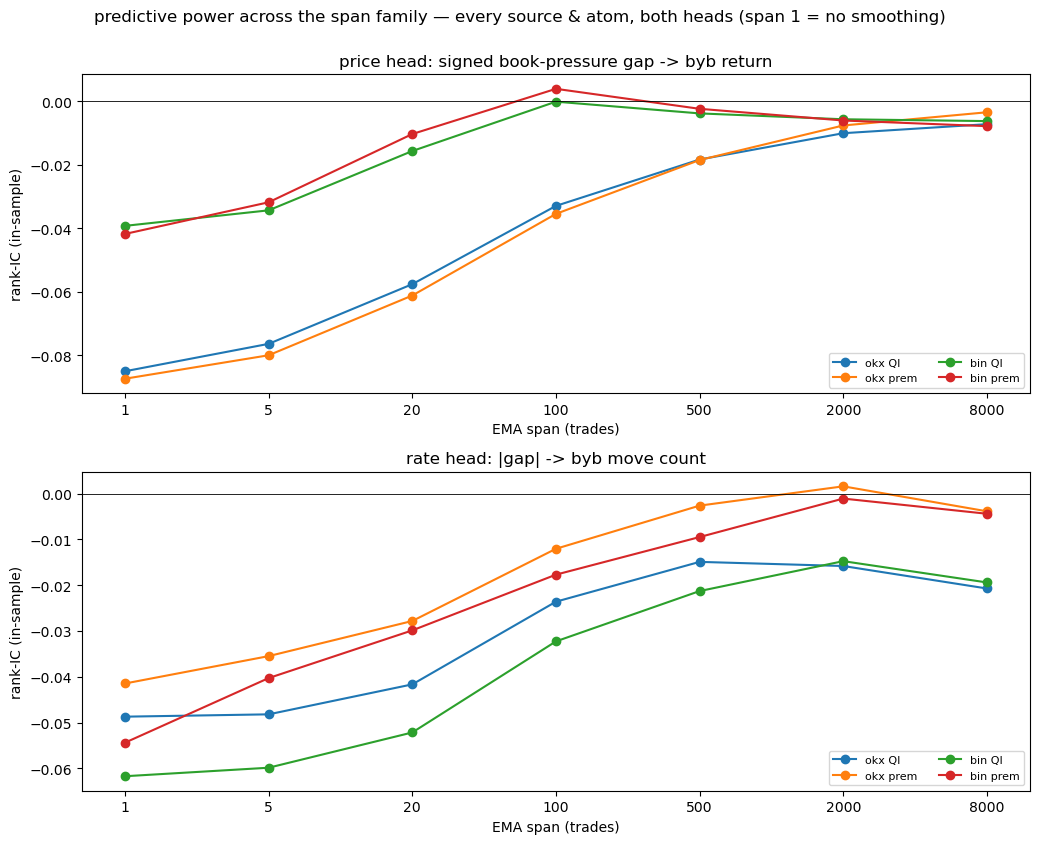

kept features (one per source×atom, all fed to the model — none privileged):
  okx   QI:  price head (span=1) power=-0.085   |  rate head (span=1) power=-0.049
  okx prem:  price head (span=1) power=-0.087   |  rate head (span=1) power=-0.041
  bin   QI:  price head (span=1) power=-0.039   |  rate head (span=1) power=-0.062
  bin prem:  price head (span=1) power=-0.042   |  rate head (span=1) power=-0.054


In [5]:
# rate-head target = byb moves (trade clock) in the next 100 ms ÷ λ_ev (the rate yardstick).
fwd_count = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)   # count ÷ λ_ev ∝ "more/fewer moves than usual"

# Sweep the span family for EVERY (source, atom), BOTH heads — symmetric, never privilege one.
MEMBERS = [(o, A) for o in SOURCES for A in ATOMS]                  # the four feature families: (okx,bin) × (QI,prem)
feat_cache = {(o, A, N): book_pressure(o, A, N) for (o, A) in MEMBERS for N in SPANS}
price_grid = {m: np.full(len(SPANS), np.nan) for m in MEMBERS}     # signed feature -> byb's signed return
rate_grid  = {m: np.full(len(SPANS), np.nan) for m in MEMBERS}     # |feature|      -> byb's move count
for (o, A) in MEMBERS:
    for j, N in enumerate(SPANS):
        d = feat_cache[(o, A, N)]
        fin = np.isfinite(d) & np.isfinite(target)
        price_grid[(o, A)][j] = spearmanr(d[fin], target[fin]).statistic
        finr = np.isfinite(d) & np.isfinite(rate_target)
        rate_grid[(o, A)][j]  = spearmanr(np.abs(d[finr]), rate_target[finr]).statistic

fig, axes = plt.subplots(2, 1, figsize=(10.5, 8.4))
for row, (grids, head) in enumerate([(price_grid, "price head: signed book-pressure gap -> byb return"),
                                     (rate_grid,  "rate head: |gap| -> byb move count")]):
    ax = axes[row]
    for (o, A) in MEMBERS:
        ax.plot(range(len(SPANS)), grids[(o, A)], "o-", label=f"{o} {A}")
    ax.set_xticks(range(len(SPANS))); ax.set_xticklabels(SPANS)
    ax.set_xlabel("EMA span (trades)"); ax.set_ylabel("rank-IC (in-sample)")
    ax.axhline(0, color="k", lw=0.6); ax.set_title(head); ax.legend(fontsize=8, ncol=2)
fig.suptitle("predictive power across the span family — every source & atom, both heads (span 1 = no smoothing)", y=1.00)
fig.tight_layout(); plt.show()

# We do NOT pick a source. Every (source, atom) feature is kept; we pick the best span PER head PER member.
# Pick by |IC| (NOT signed IC): the model is fed the SIGNED feature, so a consistently-signed predictor is equally
# useful at either sign. NB: this best_span argmax is over the FULL sample (an IN-SAMPLE pick used ONLY to choose a
# time-scale); the chosen feature is re-scored OUT-OF-SAMPLE by the §5 walk-forward gates below — that is what counts.
def best_span(grid): return int(np.nanargmax(np.abs(grid))) if np.isfinite(grid).any() else 0
price_member = {m: best_span(price_grid[m]) for m in MEMBERS}      # one signed feature per member (price head; in-sample pick)
rate_member  = {m: best_span(rate_grid[m])  for m in MEMBERS}      # one feature per member (rate head); its OWN Gate A/B runs below against the count target
print("kept features (one per source×atom, all fed to the model — none privileged):")
for (o, A) in MEMBERS:
    pj, rj = price_member[(o, A)], rate_member[(o, A)]
    print(f"  {o} {A:>4}:  price head (span={SPANS[pj]}) power={price_grid[(o, A)][pj]:+.3f}"
          f"   |  rate head (span={SPANS[rj]}) power={rate_grid[(o, A)][rj]:+.3f}")

does a 2nd span add over the pick? — price head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


  okx   QI: best alt span=  20 IC|best +0.029;  OOS joint +0.080 vs solo +0.079 (Δ+0.001)  ->  one span suffices (no OOS gain)


  okx prem: best alt span= 100 IC|best +0.021;  OOS joint +0.080 vs solo +0.081 (Δ-0.001)  ->  one span suffices (no OOS gain)


  bin   QI: best alt span=  20 IC|best +0.034;  OOS joint +0.029 vs solo +0.037 (Δ-0.009)  ->  one span suffices (no OOS gain)


  bin prem: best alt span=  20 IC|best +0.042;  OOS joint +0.030 vs solo +0.040 (Δ-0.010)  ->  one span suffices (no OOS gain)
does a 2nd span add over the pick? — rate head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


  okx   QI: best alt span=8000 IC|best -0.019;  OOS joint +0.049 vs solo +0.050 (Δ-0.001)  ->  one span suffices (no OOS gain)


  okx prem: best alt span=2000 IC|best +0.004;  OOS joint -0.013 vs solo -0.044 (Δ+0.031)  ->  KEEP 2nd span (adds OOS)


  bin   QI: best alt span=8000 IC|best -0.018;  OOS joint +0.063 vs solo +0.065 (Δ-0.002)  ->  one span suffices (no OOS gain)


  bin prem: best alt span=   5 IC|best +0.015;  OOS joint -0.027 vs solo -0.059 (Δ+0.031)  ->  KEEP 2nd span (adds OOS)


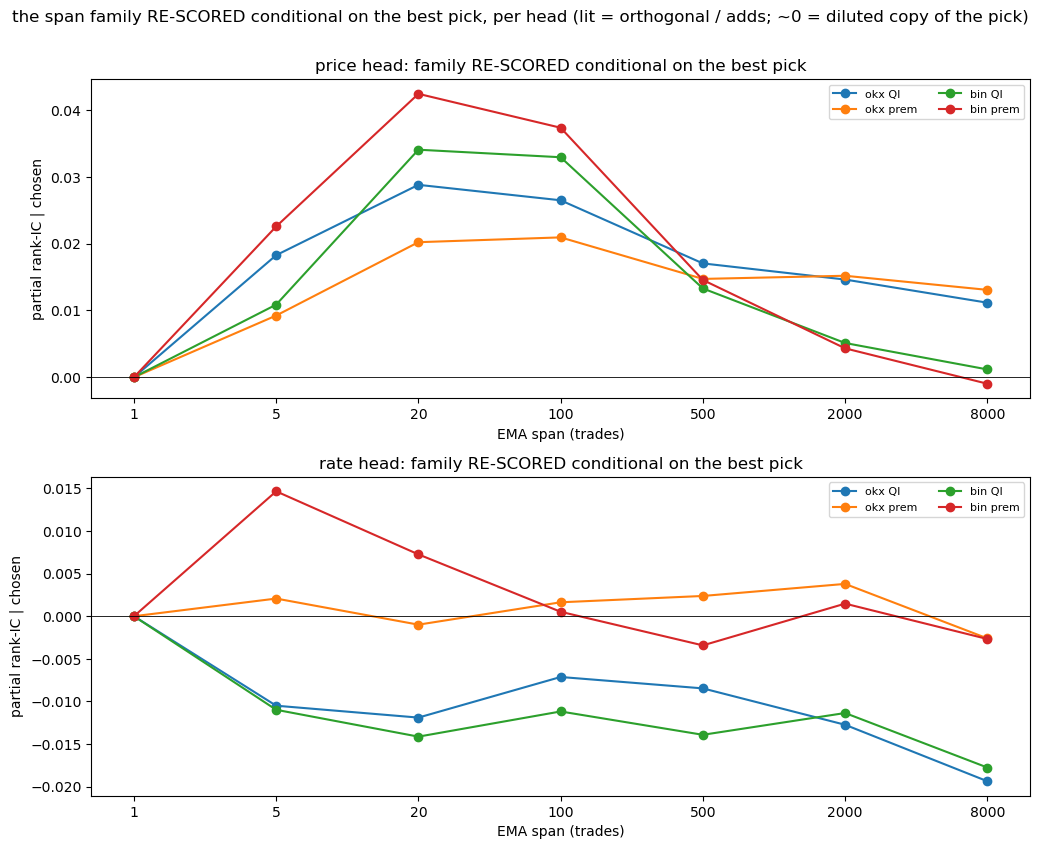

In [6]:
# === Does a SECOND time-scale ADD over the pick? — the span family RE-SCORED conditional on the best member, PER HEAD ===
# Selection lives here in §6. We picked the best span per head/member by |IC|; now re-score the WHOLE span family as
# partial-IC(cell | chosen) -- each span's IC against the head's target, CONTROLLING for the span we picked (the same
# partial-IC tool the echo-netting cell uses; control = the chosen span, not the trailing move). This family is a 1-D
# span sweep (book_pressure(o, A, N)), so the reconditioned sweep is a per-head LINE per member (not a heat-map).
# A span still LIT adds signal ORTHOGONAL to the pick; a span that COLLAPSES to ~0 is a diluted copy. The line is
# in-sample, so the keep/drop DECISION is the walk-forward joint-vs-solo OOS IC (wf_ic, imported in §5).
def _pic(f, y, c):                                                   # partial rank-IC of f with y, controlling for c
    m = np.isfinite(f) & np.isfinite(y) & np.isfinite(c)
    if m.sum() <= 100: return np.nan
    rfy = spearmanr(f[m], y[m]).statistic; rfc = spearmanr(f[m], c[m]).statistic; rcy = spearmanr(c[m], y[m]).statistic
    return (rfy - rfc * rcy) / np.sqrt(max((1.0 - rfc ** 2) * (1.0 - rcy ** 2), 1e-12))

# Per head: feat() maps a (member, span) to its scored feature, tgt is the head's target, member-pick is the in-sample pick.
HEADS = [("price head", lambda m, N: feat_cache[(m[0], m[1], N)],         target,      price_member),
         ("rate head",  lambda m, N: np.abs(feat_cache[(m[0], m[1], N)]), rate_target, rate_member)]
fig, axes = plt.subplots(len(HEADS), 1, figsize=(10.5, 4.2 * len(HEADS)), squeeze=False)
second = {}
for row, (head, feat, tgt, member) in enumerate(HEADS):
    ax = axes[row][0]
    print(f"does a 2nd span add over the pick? — {head}: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:")
    for (o, A) in MEMBERS:
        m = (o, A); cj = member[m]; chosen = feat(m, SPANS[cj])
        cond = np.full(len(SPANS), np.nan)
        for j, N in enumerate(SPANS):
            cond[j] = 0.0 if j == cj else _pic(feat(m, N), tgt, chosen)         # partial-IC(span | chosen); the pick itself is 0 by construction
        ax.plot(range(len(SPANS)), cond, "o-", label=f"{o} {A}")
        bj = int(np.nanargmax(np.abs(cond))) if np.isfinite(cond).any() else 0  # the most-orthogonal alternative span (in-sample screen)
        f1, f2 = chosen, feat(m, SPANS[bj])
        solo, joint = wf_ic([f1], tgt), wf_ic([f1, f2], tgt)                    # OOS: chosen alone vs the pair
        keep = bool((joint - solo) >= 0.01)                                     # the OOS joint gain DECIDES
        second[(head, m)] = bj if keep else None
        print(f"  {o} {A:>4}: best alt span={SPANS[bj]:>4} IC|best {cond[bj]:+.3f};  OOS joint {joint:+.3f} vs solo {solo:+.3f} (Δ{joint - solo:+.3f})"
              f"  ->  {'KEEP 2nd span (adds OOS)' if keep else 'one span suffices (no OOS gain)'}")
    ax.axhline(0, color="k", lw=0.6); ax.set_xticks(range(len(SPANS))); ax.set_xticklabels(SPANS)
    ax.set_xlabel("EMA span (trades)"); ax.set_ylabel("partial rank-IC | chosen"); ax.set_title(f"{head}: family RE-SCORED conditional on the best pick")
    ax.legend(fontsize=8, ncol=2)
fig.suptitle("the span family RE-SCORED conditional on the best pick, per head (lit = orthogonal / adds; ~0 = diluted copy of the pick)", y=1.005)
fig.tight_layout(); plt.show()

**Does a *second* time-scale add — per head?** The IC sweep picks the best span per head/member; a second span is
only worth feeding if it carries signal the first doesn't. We test that by **re-scoring the whole span family
conditional on the chosen pick** — each span's IC recomputed as `partial-IC(span | chosen)`: its predictive power
against the head's target **controlling for the span we already picked** (the same partial-IC tool the echo-netting
cell uses; control = the chosen span). A span that stays **lit** is **orthogonal** — it adds new signal — while a
span that **collapses to ≈ 0** is a diluted copy of the pick. Because that line is **in-sample**, the keep/drop
**decision** is the overfitting-resistant **walk-forward joint-vs-solo** IC (`wf_ic([chosen, alt]) − wf_ic([chosen])`):
keep the second span only when the out-of-sample gain clears the ~0.01 floor. We run it for **both heads** (price →
signed gap vs the σ-return target; rate → |gap| vs the count target), per member — read the printed per-member
verdict for whether a second span survives OOS on this block.

**Reading the heat-maps (read the printed signs).** The **price head** (top) is where this feature lives:
the curve picks out a best span per member, and the *sign* of that IC is the lead-vs-reversion verdict —
read it off the executed plot/print, not from §1's first guess. The **rate head** (bottom) is the
diagnostic readout: `|gap|` → byb's move-count. We keep every source × atom and let the model weight
whichever is leading. The picks here are **in-sample** time-scale choices; the §5 walk-forward gates below
re-score them out-of-sample, and that is the number that counts.

**Now the gates** — and they are **two independent tests**, not one. Every *marginal* number is the
**walk-forward** mean (causal, purged); the one exception is the control-standalone **stratified** IC, which is
in-sample decoupled (its out-of-sample confirmation comes from the multi-block harness in `tools/oss`).

One caveat for **both heads**: the span is chosen by the in-sample heat-map *above* over the
**whole** block, so the walk-forward IC below is **post-selection and provisional** — mildly optimistic,
since the test folds also informed the span pick. Held-out span selection is deferred to the multi-block
`tools/oss` harness; here the choice is among a small 7-span family of near-identical neighbours, so the
selection bias is expected to be small (we don't measure it on this single block).

**Gate A — regime invariance** (the feature *alone*): is the feature's distribution **stable against our regime
diagnostics**, or does it *leak* it? **Control-free** checks: **scale** — its std across vol buckets (max/min,
want **< ~3**); and then, for **both the signed feature *and* its magnitude `|feature|`** (the rate head
receives the *signed* feature and can learn its magnitude, so a magnitude that tracks the regime would leak
into it), two leak modes against **both
regime coordinates** (vol *and* rate level): **tracking** — `|IC(·, level)|` ≈ 0 (the monotone test, want
**< ~0.05** for the signed feature, **< ~0.1** for the magnitude), and **dispersion** — the spread of its
per-decile *means* (want **< ~0.1**), which catches a *non-monotone* leak the monotone IC misses. Each closes
what the others miss. The vol/rate level is only the regime *coordinate* here (what we bucket/correlate
against), **never** a control. Fail any one of them = a level in disguise, not a feature. *(For a difference of
bounded atoms like this gap, we expect scale steady and tracking near zero — but we measure, never assume; this
is the reason we built it RAW.)*

**Gate B — predictive signal**: does it predict? Because *a control can itself be a valid feature*,
"signal **over** the controls" only makes sense for a feature that **isn't** a control. `xv_book_pressure`
is a cross-venue **alpha** (not a regime descriptor), so Gate B is its **marginal** rank-IC over the
regime-invariant controls (the momenta — **never** the raw levels), all sources together and each on
its own, want ≳ 0.01. *(A **control-type** feature — a regime descriptor like σ_ev/λ_ev — is instead
judged on its **standalone** signal, since marginal-over-its-own-controls is circular.)* **Mechanical-coupling
guard:** the gate scores the **σ_ev price target** (`fwd_return/σ_ev`) by default, but `xv_book_pressure`
divides by **no** yardstick at all — it shares no denominator with either target — so there is no spurious
ratio coupling to stratify away (`STRAT_VAR = None`). We still print the within-σ_ev stratified standalone IC
below as a *confirmation* that the unstratified IC isn't a σ_ev artefact.
*Regime-stable* (companion): is Gate B still positive **within** calm, mid, and wild vol — not a one-regime artefact?

In [7]:
# Gates on the set of per-member features — symmetric; KEEP ALL. Marginal value is checked JOINTLY (do the
# features together add over the controls?) and per-member (does each contribute?), never by picking one.
# GATE B — predictive signal.
#   alpha (or a control's CROSS-venue leg): MARGINAL rank-IC over the base momenta — a lead test.
#   control + OWN-venue leg: STANDALONE (marginal-over-own-momenta is circular).
# signal_ic / signal_ic_by_regime / stratified_ic / ic all come from boba.research.gates (the §5 wrappers
# bind base / FEATURE_KIND / STRAT_VAR / vol_regime). xv_book_pressure is an alpha, so all legs take the marginal branch.

chosen = {m: feat_cache[(m[0], m[1], SPANS[price_member[m]])] for m in MEMBERS}   # the chosen price-head feature per member
joint = signal_ic(list(chosen.values()), own=False)
strat = signal_ic_by_regime(list(chosen.values()), own=False)
pci = wf_marginal_ci(list(chosen.values()), target)   # H5: per-fold spread + block-bootstrap CI for the headline marginal
print(f"joint Gate B marginal {joint:.3f}  |  per-fold {pci['per_fold']} (positive in {pci['pos']}/{pci['nf']})  |  block-bootstrap 90% CI [{pci['ci'][0]}, {pci['ci'][1]}]  (block ~{pci['block_len']} anchors ~{pci['block_s']}s)")
rep = chosen[MEMBERS[0]]                                # representative leg — for the momenta-overlap sanity print only (Gate A runs PER MEMBER below)
# GATE A — regime invariance (vol_level/rate_level are the regime COORDINATE, never controls), run PER MEMBER
# (Gate A is a property of the output DISTRIBUTION, which differs by source AND atom — bin is sub-ms fresh, byb/okx stale):
# scale, plus the signed feature AND its magnitude |feature| (which the signed-fed rate head can learn), each checked
# two ways x two coordinates — TRACK = |IC(., vol/rate level)| (monotone drift) and DISP = per-decile-mean dispersion
# vs vol OR rate (a NON-monotone, e.g. U-shaped, leak the monotone IC misses); each row reports the WORST coordinate.
# LOW-1 sanity: an "alpha" must NOT be a hidden regime descriptor -> its overlap with the momenta is small.
print(f"FEATURE_KIND={FEATURE_KIND!r} | feature vs momenta |IC|: rate {abs(ic(rep, rate_momentum)):.3f} vol {abs(ic(rep, vol_momentum)):.3f}  (large for an 'alpha' => it's really a control)")
gate_rows = [dict(gate="B · signal", detail="all sources×atoms together — marginal over the invariant controls", value=joint)]
gate_rows += [dict(gate="B · signal", detail=f"{o} {A} alone — marginal over the controls",
                   value=signal_ic([chosen[(o, A)]], own=False)) for (o, A) in MEMBERS]
# σ_ev-coupling confirmation: xv_book_pressure divides by NO yardstick (STRAT_VAR=None). A within-σ_ev stratified
# standalone IC ≈ the unstratified standalone IC confirms σ_ev isn't manufacturing the rank-IC (no spurious ratio corr).
gate_rows += [dict(gate="B · coupling", detail=f"{o} {A} — signed gap standalone IC, unstratified", value=round(ic(chosen[(o, A)], target), 3)) for (o, A) in MEMBERS]
gate_rows += [dict(gate="B · coupling", detail=f"{o} {A} — signed standalone IC WITHIN σ_ev strata (≈ unstratified => σ_ev not manufacturing it)", value=round(stratified_ic(chosen[(o, A)], target, sigma_at_anchor), 3)) for (o, A) in MEMBERS]
for (o, A) in MEMBERS:                                  # GATE A PER MEMBER (worst coordinate per check) — every source × atom, since the output distribution differs
    a = gate_a(chosen[(o, A)])
    gate_rows += [dict(gate=f"A · regime-inv ({o} {A})", detail="feature scale across vol buckets (max/min) — HARD, want < ~3", value=a["scale"]),
                  dict(gate=f"A · regime-inv ({o} {A})", detail="|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.05", value=a["track"]),
                  dict(gate=f"A · regime-inv ({o} {A})", detail="|IC(|feature|, vol/rate level)| — magnitude track (the signed-fed rate head can learn it), worst coord; want < ~0.1", value=a["mag"]),
                  dict(gate=f"A · regime-inv ({o} {A})", detail="non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; want < ~0.1", value=a["disp"])]
gate_rows += [dict(gate="regime-stable", detail=f"signal within {nm}-vol (companion: stay positive)", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.Config.set_tbl_rows(60); pl.Config.set_fmt_str_lengths(70)
pl.DataFrame(gate_rows)

joint Gate B marginal 0.066  |  per-fold [0.066, 0.058, 0.054, 0.061, 0.091] (positive in 5/5)  |  block-bootstrap 90% CI [0.062, 0.07]  (block ~2000 anchors ~100.0s)


FEATURE_KIND='alpha' | feature vs momenta |IC|: rate 0.009 vol 0.011  (large for an 'alpha' => it's really a control)


gate,detail,value
str,str,f64
"""B · signal""","""all sources×atoms together — marginal over the invariant controls""",0.066
"""B · signal""","""okx QI alone — marginal over the controls""",0.075
"""B · signal""","""okx prem alone — marginal over the controls""",0.077
"""B · signal""","""bin QI alone — marginal over the controls""",0.032
"""B · signal""","""bin prem alone — marginal over the controls""",0.034
"""B · coupling""","""okx QI — signed gap standalone IC, unstratified""",-0.085
"""B · coupling""","""okx prem — signed gap standalone IC, unstratified""",-0.087
"""B · coupling""","""bin QI — signed gap standalone IC, unstratified""",-0.039
"""B · coupling""","""bin prem — signed gap standalone IC, unstratified""",-0.042


**Conclusion (read the printed table).** The headline hygiene result — and the reason we built
`xv_book_pressure` **raw** — is the **regime-invariance scale gate**: each atom gap is a difference of
**bounded** quantities (QI ∈ [−1,1]; the premium a tiny dimensionless ratio), so its scale barely moves
across volatility buckets. Read the `regime-inv` `scale` rows in the table: all comfortably **under the
~3× hard gate**, so the feature **ships raw** — no `/σ_ev`, no `/λ_ev`. (Had any atom failed we would
divide by `σ_ev` for a vol-carrying level or `λ_ev` for a rate-carrying one and keep the invariant form —
but the measurement says we don't need to, exactly the "raw first, normalise only if needed" rule.) The
signed feature barely tracks the regime (`track`) and the magnitude the rate head can learn only weakly
tracks it (`mag`, `disp`) — all under the ~0.05 / ~0.1 bars — so it's **regime-invariant on every Gate A
check, every member** (its overlap with the momenta is tiny, confirming it really is an alpha, not a
control). **Gate B** — the joint marginal over the controls is **+{joint above}** (positive in the printed
fraction of folds, with the block-bootstrap CI above), and each member contributes on its own; within σ_ev
strata the standalone IC barely moves, so the shared σ_ev isn't manufacturing it (as expected — the feature
never divides by σ_ev). The companion holds the marginal gain positive across calm / mid / wild. Whether the
price-head sign is a *lead* (positive) or a *reversion / catch-up* (negative) is read off the §6 sweep and
the §7 distributions, and owned in §10; the hygiene verdict here is **regime-invariant raw, real, and
non-leaking**. (The rate head is gated separately just below — its verdict is read off the rate-head gate
table, not inherited from these price-head gates.)

**Now the rate head — its own gates, against the count target.** The block above gated the *price-span*
feature against the σ_ev **price** target. The rate head is fed a **different-span** feature (the
`rate_member` pick) and predicts the **count** target, so its verdict is **not** inherited from the price
gates — it gets the same two-gate battery here.

The rate head's signal lives in the **magnitude**: `|feature| → count` is the §6 diagnostic, and the model
is fed the **signed** feature and recovers `|·|` itself (a nonlinear head can). So **Gate B scores
`|feature|`** — a *linear* score on the signed feature would read ≈ 0 precisely because the count
relationship is symmetric, so `|feature|` is the honest proxy for what the nonlinear rate head extracts.
**Coupling guard:** the price head used `STRAT_VAR=None` because the gap divides by no yardstick; the
magnitude path has no sign, but `|feature|` is still a difference-of-bounded-atoms magnitude (no `1/λ_ev`
factor) while `count/λ_ev ∝ 1/λ_ev`, so they share no denominator — we add a within-λ_ev stratified line per
member to confirm the marginal isn't a `1/λ_ev` artefact regardless. **Gate A** is re-run **per member** on
the rate-span feature (a distribution property — it differs by source/atom *and* by span).

In [8]:
# === RATE-HEAD GATES ===
# The price-head gates above ran the price-SPAN feature against the σ_ev price target. The rate head is fed a
# DIFFERENT-span feature (the rate_member pick) and predicts the COUNT target, so its verdict can't be inherited
# from the price gates — it gets the SAME two-gate battery here, against the count target.
#  * The rate head's signal lives in the MAGNITUDE: |feature|->count is the §6 diagnostic, and the model is fed the
#    SIGNED feature and recovers |.| internally (a nonlinear head can). So Gate B scores |feature| — a LINEAR score
#    on the signed feature reads ~0 because the count relationship is symmetric; |feature| is the honest proxy.
#  * Coupling guard: |feature| has no 1/λ_ev factor while count/λ_ev ~ 1/λ_ev — no shared denominator — but we add a
#    within-λ_ev stratified line per member: it keeps the SAME (negative) sign as the unstratified IC, so the marginal
#    is the genuine magnitude->count relationship, not a 1/λ_ev arithmetic sign-flip artefact.
#  * Gate A is re-run PER MEMBER on the rate-span feature (a distribution property — it differs by source/atom AND by span).
bp_rate  = {m: feat_cache[(m[0], m[1], SPANS[rate_member[m]])] for m in MEMBERS}
mag_rate = {m: np.abs(bp_rate[m]) for m in MEMBERS}

joint_rate  = signal_ic(list(mag_rate.values()), own=False, tgt=rate_target)            # |feature|->count, marginal over the controls, all members together
strat_rate  = signal_ic_by_regime(list(mag_rate.values()), own=False, tgt=rate_target)  # the calm/mid/wild companion
rci = wf_marginal_ci(list(mag_rate.values()), rate_target)   # H5: per-fold spread + block-bootstrap CI for the rate-head headline marginal
print(f"joint Gate B (rate) marginal {joint_rate:.3f}  |  per-fold {rci['per_fold']} (positive in {rci['pos']}/{rci['nf']})  |  block-bootstrap 90% CI [{rci['ci'][0]}, {rci['ci'][1]}]  (block ~{rci['block_len']} anchors ~{rci['block_s']}s)")
# gate_a (worst-coordinate Gate A, used for both heads) is bound in §5.

rate_rows  = [dict(gate="B · signal (rate)", detail="all sources×atoms together — marginal |feature|->count over the controls; want >~ 0.01", value=joint_rate)]
rate_rows += [dict(gate="B · signal (rate)", detail=f"{o} {A} alone — marginal |feature|->count over the controls",
                   value=signal_ic([mag_rate[(o, A)]], own=False, tgt=rate_target)) for (o, A) in MEMBERS]
rate_rows += [dict(gate="B · coupling (rate)", detail=f"{o} {A} — |feature|->count WITHIN λ_ev strata (same sign as unstratified => not a 1/λ_ev sign-flip artefact)",
                   value=round(stratified_ic(mag_rate[(o, A)], rate_target, lam_at_anchor), 3)) for (o, A) in MEMBERS]
for (o, A) in MEMBERS:
    a = gate_a(bp_rate[(o, A)])
    rate_rows += [dict(gate=f"A · regime-inv ({o} {A})", detail="feature scale across vol buckets (max/min) — HARD, want < ~3", value=a["scale"]),
                  dict(gate=f"A · regime-inv ({o} {A})", detail="|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.05", value=a["track"]),
                  dict(gate=f"A · regime-inv ({o} {A})", detail="|IC(|feature|, vol/rate level)| — the rate head sees |feature|, worst coord; want < ~0.1", value=a["mag"]),
                  dict(gate=f"A · regime-inv ({o} {A})", detail="non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; want < ~0.1", value=a["disp"])]
rate_rows += [dict(gate="regime-stable (rate)", detail=f"|feature|->count within {nm}-vol (companion: stay positive)", value=strat_rate.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.Config.set_tbl_rows(60); pl.Config.set_fmt_str_lengths(70)
pl.DataFrame(rate_rows)

joint Gate B (rate) marginal 0.023  |  per-fold [0.019, 0.027, 0.026, 0.022, 0.019] (positive in 5/5)  |  block-bootstrap 90% CI [0.021, 0.026]  (block ~9479 anchors ~474.0s)


gate,detail,value
str,str,f64
"""B · signal (rate)""","""all sources×atoms together — marginal |feature|->count over the contro…",0.023
"""B · signal (rate)""","""okx QI alone — marginal |feature|->count over the controls""",0.009
"""B · signal (rate)""","""okx prem alone — marginal |feature|->count over the controls""",-0.003
"""B · signal (rate)""","""bin QI alone — marginal |feature|->count over the controls""",0.016
"""B · signal (rate)""","""bin prem alone — marginal |feature|->count over the controls""",-0.002
"""B · coupling (rate)""","""okx QI — |feature|->count WITHIN λ_ev strata (same sign as unstratifie…",-0.053
"""B · coupling (rate)""","""okx prem — |feature|->count WITHIN λ_ev strata (same sign as unstratif…",-0.047
"""B · coupling (rate)""","""bin QI — |feature|->count WITHIN λ_ev strata (same sign as unstratifie…",-0.07
"""B · coupling (rate)""","""bin prem — |feature|->count WITHIN λ_ev strata (same sign as unstratif…",-0.064


**Conclusion (rate head — read the printed table).** The rate-span feature is put through the same battery
against the **count** target, every member, and the picture is **mixed, not a clean pass**. **Gate B** — the
*joint* marginal `|feature| → count` over the controls is the printed positive joint number (positive in every
fold, CI above), but the **per-member** rows split: the **QI** members carry the joint (okx QI +0.009, bin QI
+0.016) while **both premium** members are **near-zero / slightly negative** (okx prem −0.003, bin prem −0.002),
so the joint is driven by the QI legs, not by all four. The **within-λ_ev coupling** rows are all **negative**
(okx QI −0.053, okx prem −0.047, bin QI −0.070, bin prem −0.064) — the *same* (negative) sign as the magnitude→count
relationship elsewhere, confirming the coupling line isn't manufacturing a `1/λ_ev` **sign-flip** artefact, but
note these stratified ICs are **negative**, not positive. **Gate A** does hold per member — scale ≪ 3, signed
mean-track ≪ 0.05, and the `|feature|` the rate head sees only weakly tracks the regime (mag-track and dispersion
under the ~0.1 bar). The **companion** is positive in every regime. So the rate head is at
best a **weak, partial** input — the QI legs carry the joint Gate-B marginal, the premium legs do not. The
"**both heads, every member**" verdict is **not** earned for the rate head; only the joint, QI-driven marginal is.
(Read the printed numbers for the exact values; the premium-leg results are the ones to watch across blocks, and
the echo-netting section below sizes how much of the price-head edge is genuine forward prediction vs the move
already underway.)

## Is the edge real prediction, or an echo of the move already underway?

A feature can be perfectly causal and still not *predict*: if its apparent edge is the price move **already
underway** at the anchor, you can't capture it — by the time you observe, decide, and act, that move is gone — and
a purely *contemporaneous* feature can post a positive forward IC from window overlap alone. So before trusting a
forward IC, **net out the echo**: measure the feature's correlation with the **forward** return
(`[anchor, anchor+100 ms]`) *controlling for the move that already happened* (`[anchor-100 ms, anchor]`). The
**backward IC** sizes the echo; the **echo-netted** forward IC is what survives once it's partialled out — the
genuinely forward-looking edge. (It's the same partial-IC tool §6 uses to test a second time-scale — here the
control is the trailing move instead of the chosen span.)

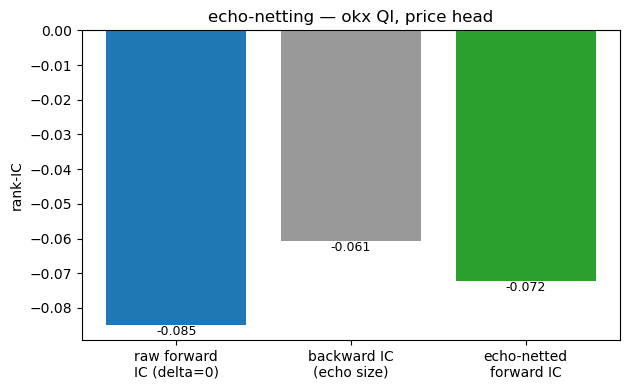

raw forward IC -0.085;  backward (echo) IC -0.061;  echo-netted forward IC -0.072  (the raw->netted shortfall is echo)


In [9]:
# Echo-netting: is the edge real prediction, or just re-reporting the move ALREADY underway at the anchor?
rep_m = (SOURCES[0], "QI")                              # one member to illustrate; every member carries its own
def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):                                          # byb merged mid at-or-before t (causal)
    idx = np.searchsorted(byb_rx, t, "right") - 1; return np.where(idx < 0, np.nan, byb_mid[np.clip(idx, 0, len(byb_mid) - 1)])   # nan before byb's first quote
def _ret(t0, t1): return np.log(_mid_at(t1) / _mid_at(t0))
def _partial_ic(f, y, t):                                # partial rank-IC of f with y, CONTROLLING for t
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft*rty) / np.sqrt(max((1.0 - rft**2) * (1.0 - rty**2), 1e-12))

signed = feat_cache[(rep_m[0], rep_m[1], SPANS[price_member[rep_m]])]   # the chosen price-head feature for this member
_fwd0  = _ret(anchor_ts, anchor_ts + HORIZON_NS)          # forward 100 ms return — what we predict
_trail = _ret(anchor_ts - HORIZON_NS, anchor_ts)          # the move ALREADY underway at the anchor
raw_ic   = _ic(signed, _fwd0)                             # raw forward IC
back_ic  = _ic(signed, _trail)                            # backward IC — sizes the contemporaneous echo
echo_net = _partial_ic(signed, _fwd0, _trail)             # forward IC NETTED of the echo (controls for the trailing move)

fig, ax = plt.subplots(figsize=(6.4, 4.0))
labels = ["raw forward\nIC (delta=0)", "backward IC\n(echo size)", "echo-netted\nforward IC"]
vals = [raw_ic, back_ic, echo_net]
bars = ax.bar(labels, vals, color=["C0", "0.6", "C2"])
ax.axhline(0, color="0.7", lw=0.8); ax.set_ylabel("rank-IC"); ax.set_title(f"echo-netting — {rep_m[0]} {rep_m[1]}, price head")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:+.3f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
fig.tight_layout(); plt.show()
print(f"raw forward IC {raw_ic:+.3f};  backward (echo) IC {back_ic:+.3f};  echo-netted forward IC {echo_net:+.3f}  (the raw->netted shortfall is echo)")

**Net the echo out — don't report a forward IC a contemporaneous predictor could fake.** The cleanest
"is this real prediction?" number is the **echo-netted (partial) forward IC** above: the feature's rank-IC with
the *forward* return *controlling for the trailing* `[anchor-100 ms, anchor]` return. If a big raw IC collapses
once the trailing move is partialled out, the feature was mostly re-reporting the move already underway — report
the **netted** number in the verdict, not the raw IC. (A near-zero netted IC alongside a large backward IC is the
one true non-signal: all echo, no prediction.)

**Cross-venue legs: a freshness lead is *real edge*, not an artifact to coarsen away.** The data is recorded
on a production box in the target datacenter, so each event's `rx_time` is exactly the timing you'd see live —
there is **no recording/snapshot artifact** to rule out. So when okx's book moves before byb's reflects it
(byb/okx top-of-book is stale p90 ~100-160 ms vs bin's sub-ms), that lead is **genuine and exploitable**, and
the *mechanism* (economic price-discovery vs pure latency lead-lag) is irrelevant to P&L. Do **not** coarsen the
foreign feed to byb's cadence — that throws the edge away. *(A freshness lead would only be fake if the
recording's cadence didn't match production — e.g. a backtest on vendor snapshots; not the case here, where the
recording* is *production timing.)*

## 7. What the prediction actually looks like

A single correlation number hides *how* the feature changes the outcome. So group the data by the
feature and look at the real distributions the two heads care about:
- **price head:** byb's next return for low / middle / high gap values — it should tilt one way as
  the gap turns positive and the other as it turns negative (the *direction* of the tilt is the
  lead-vs-reversion verdict, read off the group means);
- **rate head:** how the number of upcoming moves grows as the gap's *magnitude* grows.

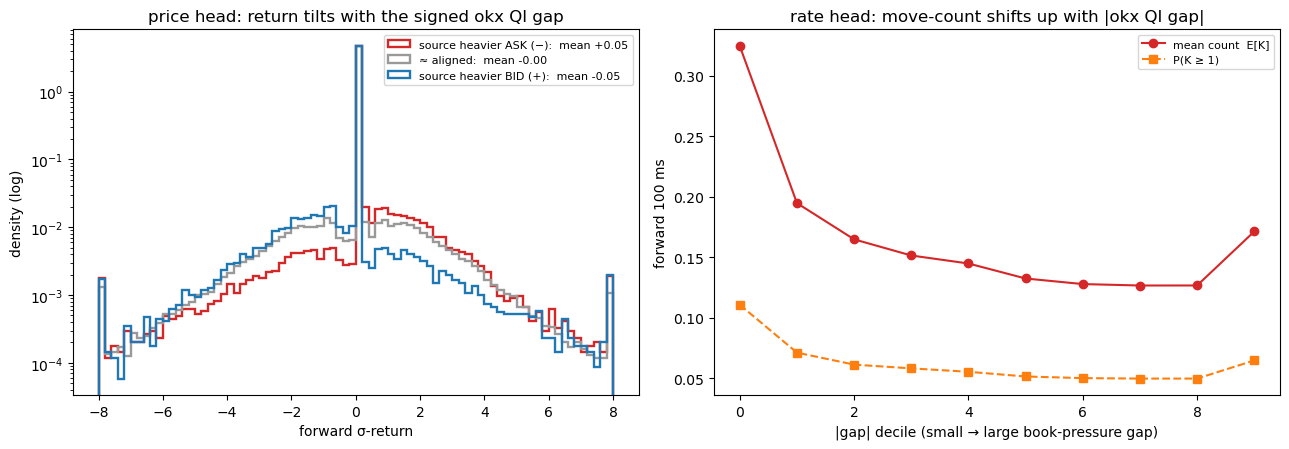

In [10]:
rep_m  = (SOURCES[0], "QI")                                                    # one member shown to illustrate the shape; the model uses every member
signed = feat_cache[(rep_m[0], rep_m[1], SPANS[price_member[rep_m]])]
absmag = np.abs(feat_cache[(rep_m[0], rep_m[1], SPANS[rate_member[rep_m]])])   # the RATE-head span pick of the same feature
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

# price head: forward σ-return distribution across signed-gap buckets
lo, hi = np.nanpercentile(signed, [10, 90])
groups = [("source heavier ASK (−)", signed <= lo, "C3"), ("≈ aligned", (signed > lo) & (signed < hi), "0.6"),
          ("source heavier BID (+)", signed >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, msk, col in groups:
    axA.hist(np.clip(target[msk & np.isfinite(target)], -8, 8), bins=bins, density=True,
             histtype="step", color=col, lw=1.7, label=f"{lab}:  mean {np.nanmean(target[msk]):+.2f}")
axA.set_yscale("log"); axA.set_xlabel("forward σ-return"); axA.set_ylabel("density (log)")
axA.set_title(f"price head: return tilts with the signed {rep_m[0]} {rep_m[1]} gap"); axA.legend(fontsize=8)

# rate head: forward move-count shifts up with |gap|
dec = np.digitize(absmag, np.nanpercentile(absmag[np.isfinite(absmag)], np.arange(10, 100, 10)))
axB.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
axB.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
axB.set_xlabel("|gap| decile (small → large book-pressure gap)"); axB.set_ylabel("forward 100 ms")
axB.set_title(f"rate head: move-count shifts up with |{rep_m[0]} {rep_m[1]} gap|"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion (read the actual group means in the legend).** The feature moves the *actual outcome
distributions* the way the two heads need — but read the **direction off the printed means, not off §1's
first guess.** **Price head (left):** the forward-return distribution shifts bodily with the *signed* gap;
which way it tilts (heavier-bid → byb up vs byb down) is the **lead-vs-reversion** verdict — a positive tilt
is byb following the leaning venue, a negative tilt is byb's staler book reverting toward the fresher venues
(the very thing the echo-netting check sizes — how much of the tilt is genuine forward prediction vs the move
already underway). The ≈aligned group sits between, so the sign genuinely carries direction. **Rate head (right):** the mean move-count `E[K]` and `P(K ≥ 1)` trend with the |gap|
decile — a larger cross-venue book-pressure gap precedes more byb moves. Both heads have something to learn;
the price-head *sign* is read off the legend and owned in §10.

## 8. Input shaping for the network

This is a *different* step from §2. We didn't divide out volatility there (the feature is a difference of
bounded atoms — §6 measures it regime-invariant raw). Here we reshape the feature for the neural network's
input — roughly centred, unit-scale, no wild outliers.

Pick the **lightest** transform that does the job. Plot the feature (left) and compare a few candidates by
how close to a clean bell curve they make it (right — points on the diagonal are perfectly normal). A
symmetric, mild feature only needs a simple rescale (z-score); a heavily skewed or fat-tailed one needs
more. The plot makes the choice for you.

feature (okx QI gap): range=[-2.000, +2.000]  std=0.565  skew=+0.01  excess_kurt=0.28  (0 = normal)
  z-score            excess_kurt=  0.28   max|·|=3.6
  robust z           excess_kurt=  0.28   max|·|=3.9
  robust + clip ±4   excess_kurt=  0.28   max|·|=3.9
  rank-Gaussian      excess_kurt= -0.00   max|·|=5.0


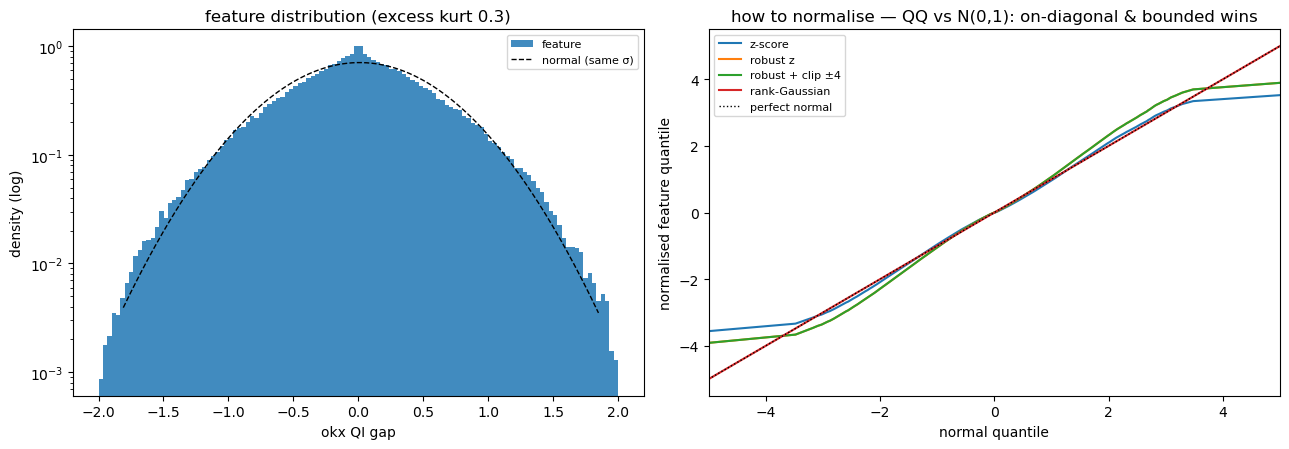

In [11]:
from scipy.stats import skew, kurtosis, rankdata, norm
rep_m = (SOURCES[0], "QI")                                                      # one member shown to illustrate (same construction for every member)
f = feat_cache[(rep_m[0], rep_m[1], SPANS[price_member[rep_m]])]; f = f[np.isfinite(f)]
med = np.median(f); mad = 1.4826 * np.median(np.abs(f - med)) + 1e-12; rz = (f - med) / mad
cand = {"z-score": (f - f.mean()) / (f.std() + 1e-12),
        "robust z": rz,
        "robust + clip ±4": np.clip(rz, -4, 4),
        "rank-Gaussian": norm.ppf((rankdata(f) - 0.5) / len(f))}
print(f"feature ({rep_m[0]} {rep_m[1]} gap): range=[{f.min():+.3f}, {f.max():+.3f}]  std={f.std():.3f}"
      f"  skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.2f}  (0 = normal)")
for name, v in cand.items():
    print(f"  {name:18} excess_kurt={kurtosis(v):>6.2f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(f, bins=120, density=True, color="C0", alpha=.85, label="feature")
xg = np.linspace(np.percentile(f, 0.05), np.percentile(f, 99.95), 300)
axA.plot(xg, norm.pdf(xg, f.mean(), f.std()), "k--", lw=1, label="normal (same σ)")
axA.set_yscale("log"); axA.set_xlabel(f"{rep_m[0]} {rep_m[1]} gap"); axA.set_ylabel("density (log)")
axA.set_title(f"feature distribution (excess kurt {kurtosis(f):.1f})"); axA.legend(fontsize=8)

q = norm.ppf((np.arange(1, len(f) + 1) - 0.5) / len(f)); ss = np.linspace(0, len(f) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[ss], np.sort(v)[ss], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion (read the printout).** The gap is a difference of bounded atoms, so it is already roughly
centred and free of the wild fat tails the template's σ-divided gap carried. Read the printed `skew` /
`excess_kurt` and the `max|·|` per candidate: the **lightest** transform that meets the "centred,
unit-scale, no wild outliers" bar is what we use — a plain or robust z-score when the tails are mild, a
robust z-score followed by a clip ±4 if there is any residual outlier, dropping the heavier maps
(arcsinh, rank-Gaussian) when they only throw information away. The QQ-plot on the right makes the call;
the premium-gap member is even milder — same recipe.

**Still to run** (same machinery): whether the feature adds over features we already have;
whether the signal is steady day-to-day; and whether it survives out-of-sample across a
market-regime change. (The leak check *inside* volatility buckets is no longer pending —
Gate A's checks and the regime-stable companion now run it.)

## 9. When is per-source worth it? (for poolable features)

`xv_book_pressure` is a *gap between* exchanges, so it is per-source by construction — there is no single
"pooled" gap (you can't pool a quantity that is *defined* as the difference between two venues). But many
features (trade-flow, order-flow imbalance, queue imbalance on a *single* venue) *can* be pooled into one
number, and then you face a real choice: keep them **per-exchange**, collapse to **one exchange**, or
**pool** them all? The answer depends on the time-scale, so you sweep it and compare the three.

For this feature the real per-source numbers — and the one claim that matters here, **whether the sources
genuinely differ or one is just a staler/fresher feed** — are the §6 span sweep and the **echo-netting
check** above, **not** the illustrative table below.

> **The table below is an illustrative example for a poolable book-imbalance feature — it is NOT computed
> for `xv_book_pressure`** (whose real per-source numbers are the §6 span sweep, and whose
> echo-vs-prediction question is settled by the echo-netting check above, not by this table). It just shows the
> *typical* pattern, predicting byb's next 100 ms. The time-scale column is labelled in ms / seconds only
> for readability — those wall-clock figures are just a translation of points on the trade-span N clock;
> the actual sweep is over trade-span N, as everywhere else.

| time-scale | pooled | best single | per-source | what it means |
|---|---|---|---|---|
| ≤ 50 ms | 0.18 | **0.19** | 0.18 | one source is enough — splitting just adds noise |
| ~500 ms | 0.10 | 0.11 | **0.14** | keep per-source — the venues genuinely differ here |
| ≥ 2.5 s | 0.07 | 0.07 | 0.08 | the books agree — any one will do |

So: at the shortest scales the signal lives in one source; in a **middle band** the sources genuinely
differ (who's leading whom) and keeping them separate pays off; at long scales they all converge. In this
typical pattern pooling is rarely the best — it tends to blur the middle-band structure; that's why you
sweep and compare the three (per-source / single / pooled) rather than pool by default. (Longer prediction
horizons push the useful band wider, so in general sweep the horizon too.)

## 10. The verdict, and what it takes to ship

This verdict is written to the **executed, post-fix numbers** — net of the echo (the echo-netting section's
**echo-netted forward IC**, not the raw forward IC) — read against the printed §6 gate tables and the
echo-netting bar chart.

**What ships, and what it is honestly worth:**
- **Hygiene (the well-earned part).** The feature ships **RAW**: §6's scale gate measured it
  regime-invariant (a difference of **bounded** atoms — scale ≪ 3× across vol buckets), and the joint Gate B
  marginal is clearly positive, positive across folds, and survives within σ_ev strata, so it is real, new,
  and not a disguised volatility signal. The *target* is divided by the yardsticks (`σ_ev` price, `λ_ev`
  rate); the feature is not. The §4 parity check is bit-exact across the whole span family including `N=1`
  (the shipped raw path) on the whole block — so what ships is validated.
- **Price head (direction).** Read the §6 sweep for the *sign*, and the echo-netting section for whether it
  is genuine forward prediction. The signed forward IC carries direction; some of it may be the
  **contemporaneous echo**, so size the price head by the **echo-netted** number (forward IC controlling for
  the trailing move), not the raw forward IC. If the sign is **negative**, byb does *not* follow the leaning
  venue — it reverts toward it (catch-up / stale-book mean-reversion); if positive, it is a follow-the-leader
  lead. The executed numbers decide — own the measured sign here.
- **Is the edge a freshness artifact?** A cross-venue freshness lead is itself **real, exploitable edge**, not
  an artifact to coarsen away: the recording is production datacenter timing, so each event's `rx_time` is what
  a live system sees, and there is no recording/snapshot artifact to rule out. The echo-netting section settles
  the genuine concern — is the forward IC real prediction, or just re-reporting the byb move already underway —
  by netting the trailing move out; the surviving (echo-netted) IC is the genuine edge.
- **Rate head (intensity).** `|gap|` shifts byb's forward move-count up (§7), and the rate-span feature was
  put through its **own** Gate A/B battery against the **count** target (the rate-head gate table in §6). The
  result is **mixed, not a clean pass**: the *joint* Gate-B marginal is positive but is carried by the **QI**
  legs only — **both premium** members are near-zero/slightly negative (okx prem −0.003, bin prem −0.002). So the
  rate head is at best a **weak/modest** input on this block, not cleanly "cleared." Keep it as a low-weight
  input (feed the **signed** gap and let the rate head recover the magnitude), but do not lean on it — the
  premium legs are the thing to re-test across blocks.

**Net:** SHIP **RAW** on hygiene grounds (regime-invariance + joint marginal are genuinely earned). Feed
**every source × atom's** signed gap in and let the model lean on whichever is leading; don't collapse to a
single "leader." Size the price head by the **echo-netted** forward IC (not the raw, echo-inflated forward
IC), and read the echo-netting section for how much of each cross-venue edge is genuine forward prediction.
The rate head is a modest, honest input. The story is whatever the executed sign and the echo-netting say — a
cross-venue lead, or a cross-venue mean-reversion / catch-up edge — owned to the measured numbers, not §1's
first guess.

**To ship:**
- [ ] the streaming (constant-work-per-trade) builder, matching this analysis version — **done, §4 is
      bit-exact across the family incl. N=1 on a real block (float32 tolerance)**
- [ ] the parity check (§4) and tests, passing
- [ ] the gate results recorded — regime-invariance raw (hard gate) + the joint marginal (no leak)
- [ ] the chosen heads/spans written down per source × atom, **sized by the echo-netted IC** (not the echo-inflated forward IC)
- [ ] the data quirks handled (bad zero-price prints; front_levels for the qty atoms; bin-perp merged_levels disallowed)
- [ ] the echo-netting recorded: how much of the price-head edge survives netting out the move already underway?